# Pilot Event Annotation

Phase B uses AI-assisted, deep-reviewed pilot annotations with selective web verification.
Human review was not performed for this pilot, so REVIEW rows are retained and reported separately.
Analysis reads the AI-assisted CSV; no completed annotation file is required or created.


## Paths

In [1]:
import hashlib
import json
import sys
import tempfile
from base64 import b64encode
from datetime import datetime, timezone
from html import escape
from io import BytesIO
from pathlib import Path, PurePosixPath

import numpy as np
import pandas as pd
from IPython.display import HTML, display
from PIL import Image

working_directory = Path.cwd().resolve()
project_root = None
for directory in (working_directory, *working_directory.parents):
    if (directory / "data/manifests/pilot_queries.parquet").is_file():
        project_root = directory
        break
assert project_root is not None, "STOP: launch from this project or its notebooks directory"
assert Path(sys.prefix).name == "major-project", f"STOP: select major-project; current interpreter: {sys.executable}"
annotation_editing_enabled = False
image_root = project_root / "data/pilot/images/pilot_images"
retrieval_dir = project_root / "outputs/pilot/faiss_retrieval"
annotation_dir = project_root / "outputs/pilot/event_annotation"
assert image_root.is_dir(), f"STOP: missing local image root: {image_root}"
assert retrieval_dir.is_dir(), f"STOP: missing retrieval directory: {retrieval_dir}"
print("Project:", project_root)
print("Image root:", image_root)
print("Interpreter:", sys.executable)

Project: /Users/nirajmac/Documents/MajorProject
Image root: /Users/nirajmac/Documents/MajorProject/data/pilot/images/pilot_images
Interpreter: /opt/anaconda3/envs/major-project/bin/python


## Load Data

In [2]:
manifest_dir = project_root / "data/manifests"
pilot_queries = pd.read_parquet(manifest_dir / "pilot_queries.parquet")
pilot_evidence = pd.read_parquet(manifest_dir / "pilot_evidence.parquet")
retrieval_tables = {}
for channel in ("image_to_image", "image_to_text"):
    retrieval_tables[channel] = pd.read_parquet(retrieval_dir / f"{channel}_filtered.parquet")
with (retrieval_dir / "retrieval_config.json").open(encoding="utf-8") as handle:
    retrieval_config = json.load(handle)
with (retrieval_dir / "retrieval_metrics.json").open(encoding="utf-8") as handle:
    retrieval_metrics = json.load(handle)
input_files = list(manifest_dir.glob("pilot_*.parquet"))
input_files += [retrieval_dir / f"{channel}_filtered.parquet" for channel in retrieval_tables]
input_files += [retrieval_dir / "retrieval_config.json", retrieval_dir / "retrieval_metrics.json"]
input_hashes = {str(path.relative_to(project_root)): hashlib.sha256(path.read_bytes()).hexdigest()
                for path in input_files}
assert len(pilot_queries) == 200 and len(pilot_evidence) == 5000
assert pilot_queries["query_id"].is_unique and pilot_evidence["id"].is_unique
assert pd.api.types.is_bool_dtype(pilot_queries["falsified"])
assert retrieval_config["index_type"] == "IndexFlatIP" and retrieval_config["raw_k"] == 50
assert retrieval_config["query_count"] == 200 and retrieval_config["evidence_corpus_size"] == 5000
print("Loaded 2 filtered retrieval Parquets and 2 retrieval JSON files; no raw or text→text candidates used.")

Loaded 2 filtered retrieval Parquets and 2 retrieval JSON files; no raw or text→text candidates used.


In [3]:
def validate_retrieval_alignment(table, channel):
    required = ["query_row", "query_id", "image_id", "query_image_path", "submitted_caption",
                "evidence_id", "evidence_image_path", "evidence_caption", "evidence_source",
                "filtered_rank", "similarity", "retrieval_channel"]
    assert set(required).issubset(table.columns), f"STOP: missing {channel} columns"
    assert not table[required].isna().any().any(), f"STOP: null retrieval metadata: {channel}"
    assert set(table["retrieval_channel"]) == {channel}
    assert set(table["query_row"]) == set(range(200))
    assert np.isfinite(table["similarity"]).all()
    assert not table.duplicated(["query_row", "filtered_rank"]).any()
    assert not table.duplicated(["query_row", "evidence_id"]).any()
    assert pd.api.types.is_integer_dtype(table["query_row"])
    assert pd.api.types.is_integer_dtype(table["filtered_rank"])
    queries = pilot_queries.iloc[table["query_row"].to_numpy()]
    evidence = pilot_evidence.set_index("id").loc[table["evidence_id"]]
    for column in ("query_id", "image_id", "query_image_path", "submitted_caption", "falsified", "source_dataset"):
        assert table[column].tolist() == queries[column].tolist(), f"STOP: {channel} query {column} mismatch"
    for result_column, manifest_column in (("evidence_image_path", "image_path"),
                                          ("evidence_caption", "caption"), ("evidence_source", "source")):
        assert table[result_column].tolist() == evidence[manifest_column].tolist(), f"STOP: {channel} evidence mismatch"
    for query_row, group in table.groupby("query_row", sort=False):
        assert group["filtered_rank"].tolist() == list(range(1, len(group) + 1)), f"STOP: invalid ranks: {query_row}"
        assert len(group) == 50, f"STOP: expected 50 filtered candidates: {query_row}"
    if channel == "image_to_image":
        assert not table["evidence_image_path"].eq(table["query_image_path"]).any()
        assert not table["evidence_id"].eq(table["image_id"]).any()
        assert not table["is_known_exact_duplicate"].any()

for channel, table in retrieval_tables.items():
    validate_retrieval_alignment(table, channel)
print("Both filtered retrieval tables match the local frozen manifests and retain valid ranks.")

Both filtered retrieval tables match the local frozen manifests and retain valid ranks.


## Select Queries

In [4]:
seed = 42
image_image_depth = 5
image_text_depth = 5
allowed_event_labels = ["SAME_EVENT", "RELATED_DIFFERENT_EVENT", "IRRELEVANT"]
allowed_confidence_values = ["HIGH", "MEDIUM", "LOW"]
allowed_review_statuses = ["UNLABELED", "LABELED", "REVIEW"]
available_counts = pilot_queries.groupby(["falsified", "source_dataset"]).size().unstack(fill_value=0)
display(available_counts)
random_generator = np.random.default_rng(seed)
selected_query_rows = []
for falsified in (False, True):
    for category in (0, 1, 2, 3):
        eligible = pilot_queries.index[
            pilot_queries["falsified"].eq(falsified) & pilot_queries["source_dataset"].eq(category)
        ].to_numpy()
        assert len(eligible) >= 5, f"STOP: fewer than 5 queries for falsified={falsified}, source_dataset={category}"
        selected_query_rows.extend(random_generator.choice(eligible, size=5, replace=False).tolist())
random_generator.shuffle(selected_query_rows)
selected_queries = pilot_queries.iloc[selected_query_rows].copy()
selected_queries.insert(0, "query_row", selected_query_rows)
assert len(selected_queries) == 40 and selected_queries["query_id"].is_unique
assert selected_queries.groupby(["falsified", "source_dataset"]).size().eq(5).all()
display(selected_queries.groupby(["falsified", "source_dataset"]).size().rename("selected").unstack())
print("Selected 40 queries: 20 pristine, 20 falsified; 5 per category in each group.")

Selected 40 queries: 20 pristine, 20 falsified; 5 per category in each group.


source_dataset,0,1,2,3
falsified,,,,
False,25,25,25,25
True,25,25,25,25


source_dataset,0,1,2,3
falsified,,,,
False,5,5,5,5
True,5,5,5,5


## Build Candidates

Union filtered Top-5 by evidence ID; one row can retain both channel ranks and scores.
Add the image-side provenance anchor only if absent. Anchors receive no automatic event label.

In [5]:
known_duplicate_paths = [
    "visual_news/origin/usa_today/images/0316/125.jpg",
    "visual_news/origin/usa_today/images/0627/512.jpg",
]
evidence_by_id = pilot_evidence.set_index("id", drop=False)

def make_annotation_row(query, evidence_id):
    evidence = evidence_by_id.loc[evidence_id]
    candidate_path = evidence["image_path"]
    query_path = query["query_image_path"]
    query_linked_duplicate = query_path in known_duplicate_paths and candidate_path in known_duplicate_paths
    query_linked_duplicate = query_linked_duplicate and query_path != candidate_path
    return {
        "query_row": int(query["query_row"]), "query_id": query["query_id"], "image_id": int(query["image_id"]),
        "query_image_path": query_path, "submitted_caption": query["submitted_caption"],
        "falsified": bool(query["falsified"]), "source_dataset": int(query["source_dataset"]),
        "candidate_evidence_id": int(evidence_id), "candidate_image_path": candidate_path,
        "candidate_caption": evidence["caption"], "candidate_title": evidence["title"],
        "candidate_source": evidence["source"], "candidate_timestamp": evidence["timestamp"],
        "retrieved_by_image_image": False, "image_image_rank": pd.NA, "image_image_similarity": np.nan,
        "retrieved_by_image_text": False, "image_text_rank": pd.NA, "image_text_similarity": np.nan,
        "is_provenance_anchor": evidence_id == query["image_id"],
        "is_exact_query_image": candidate_path == query_path or evidence_id == query["image_id"],
        "is_known_exact_duplicate": candidate_path in known_duplicate_paths,
        "is_query_linked_duplicate": query_linked_duplicate,
        "known_duplicate_group": "known_sha256_pair_1" if candidate_path in known_duplicate_paths else "",
        "event_label": "", "annotation_confidence": "", "annotation_note": "", "review_status": "UNLABELED",
    }

In [6]:
annotation_rows = []
anchors_added = 0
for _, query in selected_queries.iterrows():
    candidates_by_id = {}
    for channel, prefix, depth in (("image_to_image", "image_image", image_image_depth),
                                   ("image_to_text", "image_text", image_text_depth)):
        table = retrieval_tables[channel]
        top_candidates = table.loc[table["query_row"].eq(query["query_row"]) & table["filtered_rank"].le(depth)]
        assert len(top_candidates) == depth
        for candidate in top_candidates.itertuples(index=False):
            evidence_id = int(candidate.evidence_id)
            if evidence_id not in candidates_by_id:
                candidates_by_id[evidence_id] = make_annotation_row(query, evidence_id)
            record = candidates_by_id[evidence_id]
            record[f"retrieved_by_{prefix}"] = True
            record[f"{prefix}_rank"] = int(candidate.filtered_rank)
            record[f"{prefix}_similarity"] = float(candidate.similarity)
    anchor_id = int(query["image_id"])
    if anchor_id not in candidates_by_id:
        candidates_by_id[anchor_id] = make_annotation_row(query, anchor_id)
        anchors_added += 1
    annotation_rows.extend(candidates_by_id.values())
annotation_template = pd.DataFrame(annotation_rows)
annotation_template.insert(0, "annotation_id", [f"A{number:04d}" for number in range(1, len(annotation_template) + 1)])
for column in ("image_image_rank", "image_text_rank"):
    annotation_template[column] = annotation_template[column].astype("Int64")
for column in ("candidate_title", "candidate_timestamp"):
    annotation_template[column] = annotation_template[column].fillna("")
assert not annotation_template.duplicated(["query_id", "candidate_evidence_id"]).any()
assert annotation_template["event_label"].eq("").all()
assert annotation_template["annotation_confidence"].eq("").all()
assert annotation_template["review_status"].eq("UNLABELED").all()
workload_counts = annotation_template.groupby("query_row").size()
retrieved_rows = annotation_template.loc[annotation_template["retrieved_by_image_image"] | annotation_template["retrieved_by_image_text"]]
retrieved_counts = retrieved_rows.groupby("query_row").size()
workload_summary = {
    "annotation_rows": len(annotation_template), "mean_candidates_per_query": float(workload_counts.mean()),
    "min_candidates_per_query": int(workload_counts.min()), "max_candidates_per_query": int(workload_counts.max()),
    "retrieved_unique_rows": len(retrieved_rows), "mean_retrieved_candidates": float(retrieved_counts.mean()),
    "provenance_anchor_count": int(annotation_template["is_provenance_anchor"].sum()), "anchors_added": anchors_added,
}
display(pd.DataFrame([workload_summary]))

,annotation_rows,mean_candidates_per_query,min_candidates_per_query,max_candidates_per_query,retrieved_unique_rows,mean_retrieved_candidates,provenance_anchor_count,anchors_added
0,371,9.275,8,11,366,9.15,40,5


## Validate Images

In [7]:
def resolve_image_path(stored_path):
    relative = PurePosixPath(str(stored_path))
    if relative.is_absolute() or ".." in relative.parts or relative.parts[:2] != ("visual_news", "origin"):
        raise ValueError(f"STOP: invalid stored image path: {stored_path}")
    full_path = image_root.joinpath(*relative.parts).resolve()
    if not full_path.is_relative_to(image_root.resolve()):
        raise ValueError(f"STOP: image path leaves local root: {full_path}")
    return full_path

required_image_paths = sorted(set(annotation_template["query_image_path"]) | set(annotation_template["candidate_image_path"]))
image_failures = []
for stored_path in required_image_paths:
    full_path = resolve_image_path(stored_path)
    try:
        with Image.open(full_path) as original:
            rgb = original.convert("RGB")
            rgb.load()
    except Exception as error:
        image_failures.append(f"{full_path}: {type(error).__name__}: {error}")
if image_failures:
    print("\n".join(image_failures))
    raise RuntimeError(f"STOP: {len(image_failures)} selected images are missing or unreadable")
pair_hashes = [hashlib.sha256(resolve_image_path(path).read_bytes()).hexdigest() for path in known_duplicate_paths]
assert pair_hashes[0] == pair_hashes[1], "STOP: known byte-identical pair no longer matches"
print(f"All {len(required_image_paths)} unique selected image paths exist and are readable; original images unchanged.")
print("Known duplicate pair verified by SHA-256.")

All 356 unique selected image paths exist and are readable; original images unchanged.
Known duplicate pair verified by SHA-256.


## Annotation Template

The frozen template is used for alignment and protected-metadata validation.
Judge the query-image occurrence; same person, topic, team or location alone does not establish SAME_EVENT.


In [8]:
source_distribution = []
for (falsified, category), count in selected_queries.groupby(["falsified", "source_dataset"]).size().items():
    source_distribution.append({"falsified": bool(falsified), "source_dataset": int(category), "query_count": int(count)})
event_annotation_config = {
    "seed": seed, "selected_query_count": len(selected_queries),
    "pristine_query_count": int((~selected_queries["falsified"]).sum()),
    "falsified_query_count": int(selected_queries["falsified"].sum()),
    "source_dataset_distribution": source_distribution, "selected_query_rows": selected_query_rows,
    "image_image_depth": image_image_depth, "image_text_depth": image_text_depth,
    "candidate_merge_rule": "union by (query_id, evidence_id); preserve both channel ranks/scores",
    "unique_annotation_rows": len(annotation_template), **workload_summary,
    "known_duplicate_handling": "flag either pair member; retain rows; group visual duplicates in non-trivial evaluation",
    "is_known_exact_duplicate_definition": "candidate is a member of the known byte-identical pair",
    "is_query_linked_duplicate_definition": "candidate is the known counterpart of this query image",
    "allowed_event_labels": allowed_event_labels, "allowed_confidence_values": allowed_confidence_values,
    "allowed_review_statuses": allowed_review_statuses, "project_root": str(project_root),
    "local_image_root": str(image_root), "retrieval_directory": str(retrieval_dir),
    "retrieval_files_loaded": 4, "required_unique_image_paths": len(required_image_paths),
    "input_sha256": input_hashes, "creation_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "event_labels_automatically_generated": False,
    "timestamp_semantics": "article-associated metadata; not asserted event/capture date",
    "primary_evaluation": "retrieved Top-5, excluding exact self/query-linked duplicate; one known visual group per query/channel",
    "inclusive_evaluation": "report separately; includes trivial retrieved provenance, never anchor-only rows",
}

In [9]:
editable_columns = ["event_label", "annotation_confidence", "annotation_note", "review_status"]
rank_columns = ["image_image_rank", "image_text_rank"]
similarity_columns = ["image_image_similarity", "image_text_similarity"]

def read_annotation_file(path):
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    nullable_columns = {column: [""] for column in rank_columns + similarity_columns}
    return pd.read_csv(path, keep_default_na=False, na_values=nullable_columns)


def compare_annotation_tables(expected, actual, columns):
    issues = []
    if set(expected["annotation_id"]) != set(actual["annotation_id"]):
        raise ValueError("STOP: annotation ID set changed")
    expected = expected.set_index("annotation_id").sort_index()
    actual = actual.set_index("annotation_id").sort_index()
    for column in columns:
        if column == "annotation_id":
            continue
        left, right = expected[column], actual[column]
        if pd.api.types.is_numeric_dtype(left) and not pd.api.types.is_bool_dtype(left):
            right_numeric = pd.to_numeric(right, errors="coerce")
            same = np.isclose(left.to_numpy(dtype=float, na_value=np.nan), right_numeric.to_numpy(dtype=float, na_value=np.nan),
                              rtol=1e-12, atol=1e-12, equal_nan=True)
            same &= left.isna().to_numpy() == right.isna().to_numpy()
        else:
            same = left.fillna("").astype(str).to_numpy() == right.fillna("").astype(str).to_numpy()
        if not same.all():
            changed_ids = expected.index[~same].tolist()
            issues.append(f"{column} changed for annotation IDs {changed_ids[:10]}")
    if issues:
        raise ValueError("STOP: " + "; ".join(issues))

In [10]:
def write_annotation_artifact(path, writer, validator):
    temporary = tempfile.NamedTemporaryFile(dir=path.parent, prefix=f".{path.name}.", suffix=path.suffix, delete=False)
    temporary.close()
    temporary_path = Path(temporary.name)
    try:
        writer(temporary_path)
        validator(temporary_path)
        temporary_path.replace(path)
        validator(path)
    finally:
        temporary_path.unlink(missing_ok=True)


def check_template_file(path):
    reloaded = read_annotation_file(path)
    assert len(reloaded) == len(annotation_template) and reloaded["annotation_id"].is_unique
    assert set(reloaded.columns) == set(annotation_template.columns)
    compare_annotation_tables(annotation_template, reloaded, list(annotation_template.columns))


def check_config_file(path):
    with path.open(encoding="utf-8") as handle:
        saved_config = json.load(handle)
    current = dict(event_annotation_config)
    current["creation_timestamp_utc"] = saved_config["creation_timestamp_utc"]
    assert saved_config == current, "STOP: existing batch/config differs; preserve annotations and review the mismatch"


def check_image_list(path):
    assert path.read_text(encoding="utf-8").splitlines() == required_image_paths

In [11]:
existing_phase_a_files = {
    'pilot_event_annotation_template.parquet': check_template_file,
    'pilot_event_annotation_template.csv': check_template_file,
    'event_annotation_config.json': check_config_file,
    'annotation_image_paths.txt': check_image_list
}
for filename, validator in existing_phase_a_files.items():
    path = annotation_dir / filename
    if not path.is_file():
        raise ValueError('STOP: missing frozen Phase A artifact: ' + filename)
    validator(path)
print('Existing Phase A artifacts validated; none rewritten.')
print('Phase B source: pilot_event_annotations_ai_assisted.csv')


Existing Phase A artifacts validated; none rewritten.
Phase B source: pilot_event_annotations_ai_assisted.csv


## Annotation Review

SAME_EVENT: same real-world occurrence or original image context.
RELATED_DIFFERENT_EVENT: meaningfully related, but another occurrence.
IRRELEVANT: no meaningful event-level context, even if appearance or broad topic overlaps.

The target is the query image, not the truthfulness of its submitted caption.
Captions, titles, and article timestamps support event judgment; none automatically determine the label.

Review order (query rows): [199, 118, 162, 85, 168, 80, 67, 134, 92, 195, 15, 147, 115, 104, 26, 44, 54, 86, 24, 42, 58, 182, 145, 1, 36, 106, 47, 144, 150, 196, 184, 17, 121, 153, 61, 141, 160, 10, 98, 59]



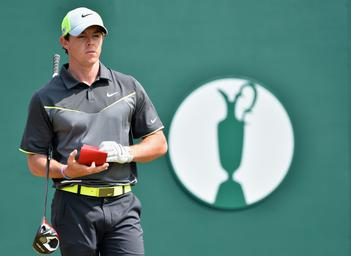
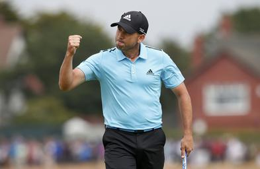
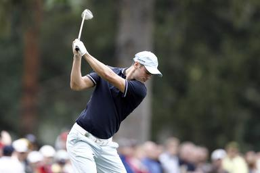
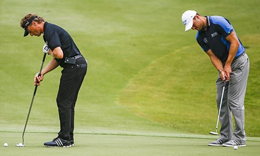
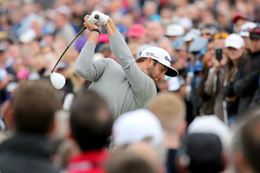
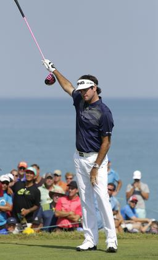
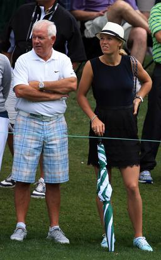
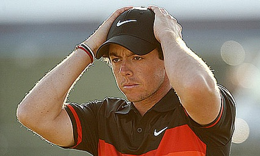
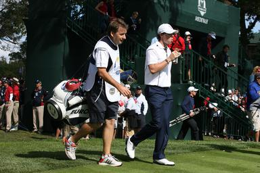
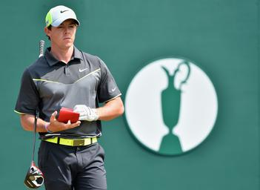
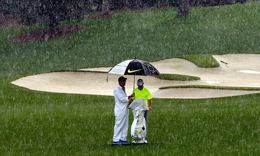

In [12]:
def image_html(stored_path, width):
    with Image.open(resolve_image_path(stored_path)) as original:
        thumbnail = original.convert("RGB")
        thumbnail.thumbnail((width, width))
    buffer = BytesIO()
    thumbnail.save(buffer, format="PNG")
    encoded = b64encode(buffer.getvalue()).decode("ascii")
    return f'<img src="data:image/png;base64,{encoded}" style="max-width:100%;max-height:{width}px" alt="{escape(stored_path)}">'


def review_query(query_row):
    rows = annotation_template.loc[annotation_template["query_row"].eq(query_row)]
    if rows.empty:
        raise ValueError(f"Query row {query_row} is not in this annotation batch")
    query = pilot_queries.iloc[query_row]
    header = f'<h3>Query {escape(query["query_id"])}, row {query_row}</h3>'
    header += image_html(query["query_image_path"], 480)
    header += f'<p><strong>Submitted caption:</strong> {escape(query["submitted_caption"])}</p>'
    header += '<p>Judge the query image occurrence. Leave uncertain cases for review; metadata is supporting context.</p>'
    header += f'<details><summary>Image-associated caption for context</summary>{escape(query["query_image_original_caption"])}</details>'
    cards = []
    for candidate in rows.itertuples(index=False):
        channels = []
        if candidate.retrieved_by_image_image:
            channels.append(f"image→image #{candidate.image_image_rank}, cosine {candidate.image_image_similarity:.4f}")
        if candidate.retrieved_by_image_text:
            channels.append(f"image→text #{candidate.image_text_rank}, cosine {candidate.image_text_similarity:.4f}")
        if not channels:
            channels.append("Added provenance anchor; not a retrieved Top-5 result")
        context = f'Title: {escape(candidate.candidate_title)}<br>Article timestamp: {escape(candidate.candidate_timestamp)}'
        context += f'<br>Anchor: {candidate.is_provenance_anchor}; exact query image: {candidate.is_exact_query_image}; known duplicate group: {escape(candidate.known_duplicate_group)}'
        card = f'<div style="border:1px solid #999;padding:10px"><strong>{candidate.annotation_id}</strong><br>'
        card += image_html(candidate.candidate_image_path, 260)
        card += f'<p>{escape(candidate.candidate_caption)}</p><p>{"<br>".join(channels)}</p>'
        card += f'<p>Source: {escape(candidate.candidate_source)}</p><details><summary>Supporting metadata</summary>{context}</details></div>'
        cards.append(card)
    grid = '<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(250px,1fr));gap:12px">'
    display(HTML(header + grid + ''.join(cards) + '</div>'))

print("Review order (query rows):", selected_query_rows)
review_query(selected_query_rows[0])

## AI-Assisted Review

Historical first-pass helpers preserve explicit image-event proposals. They do not derive labels from truth fields or retrieval scores.
Original captions, titles, sources and article timestamps support event identification; timestamps are not capture dates.
SAME_EVENT needs the same occurrence; RELATED_DIFFERENT_EVENT needs a meaningful connection to another occurrence.

The completed deep review is stored in the AI-assisted CSV. REVIEW flags remain unresolved uncertainty.
Annotation editing is disabled during Phase B; use the Phase B Source section to load and analyze the saved file.


In [13]:
import hashlib
import tempfile
from pathlib import Path, PurePosixPath

import pandas as pd
from IPython.display import display
from PIL import Image

working_dir = Path.cwd().resolve()
project_root = None
for directory in [working_dir, *working_dir.parents]:
    if (directory / 'data/manifests/pilot_queries.parquet').is_file():
        project_root = directory
        break
if project_root is None:
    raise ValueError('Launch from the project or its notebooks folder.')

annotation_dir = project_root / 'outputs/pilot/event_annotation'
image_root = project_root / 'data/pilot/images/pilot_images'
template_path = annotation_dir / 'pilot_event_annotation_template.csv'
ai_path = annotation_dir / 'pilot_event_annotations_ai_assisted.csv'
queue_path = annotation_dir / 'pilot_event_review_queue.csv'
template_hash = hashlib.sha256(template_path.read_bytes()).hexdigest()

ai_editable = ['event_label', 'annotation_confidence', 'annotation_note', 'review_status']
web_columns = ['web_checked', 'web_evidence_note']
deep_columns = ['confidence_score', 'needs_review', 'deep_reviewed']
event_labels = ['SAME_EVENT', 'RELATED_DIFFERENT_EVENT', 'IRRELEVANT']
confidence_values = ['HIGH', 'MEDIUM', 'LOW']
status_values = ['UNLABELED', 'LABELED', 'REVIEW']


def read_ai_csv(path):
    # Strings retain IDs, scores, flags, and empty metadata exactly as stored.
    return pd.read_csv(path, dtype=str, keep_default_na=False)


ai_template = read_ai_csv(template_path)
protected_columns = []
for column in ai_template.columns:
    if column not in ai_editable:
        protected_columns.append(column)


def validate_ai_annotations(table):
    required_columns = set(ai_template.columns)
    missing_columns = required_columns - set(table.columns)
    extra_columns = set(table.columns) - required_columns - set(web_columns + deep_columns)
    if missing_columns or extra_columns:
        raise ValueError('Annotation columns changed.')
    if len(table) != len(ai_template):
        raise ValueError('Annotation row count changed.')
    expected_ids = ai_template['annotation_id'].tolist()
    if table['annotation_id'].tolist() != expected_ids:
        raise ValueError('Annotation IDs or row order changed.')
    expected_metadata = ai_template[protected_columns]
    actual_metadata = table[protected_columns]
    pd.testing.assert_frame_equal(expected_metadata, actual_metadata)
    for column, allowed in [('event_label', event_labels),
                            ('annotation_confidence', confidence_values),
                            ('review_status', status_values)]:
        allowed_values = [''] + allowed
        if not table[column].isin(allowed_values).all():
            raise ValueError('Invalid value in ' + column)
    proposed = table['event_label'].ne('')
    active = proposed & table['review_status'].ne('UNLABELED')
    if not table.loc[active, 'annotation_confidence'].isin(confidence_values).all():
        raise ValueError('A proposed label needs confidence.')
    if not table.loc[active, 'review_status'].isin(['LABELED', 'REVIEW']).all():
        raise ValueError('A proposed label needs LABELED or REVIEW status.')
    if table.loc[active, 'annotation_note'].str.strip().eq('').any():
        raise ValueError('A proposed label needs a short note.')
    low = active & table['annotation_confidence'].eq('LOW')
    if not table.loc[low, 'review_status'].eq('REVIEW').all():
        raise ValueError('LOW confidence must remain REVIEW.')
    if 'web_checked' in table:
        if not table['web_checked'].isin(['True', 'False']).all():
            raise ValueError('web_checked must be True or False.')
        checked = table['web_checked'].eq('True')
        if 'web_evidence_note' not in table:
            raise ValueError('Missing web evidence notes.')
        if table.loc[checked, 'web_evidence_note'].str.strip().eq('').any():
            raise ValueError('Web checks need a factual note or unresolved-search reason.')


def load_annotations():
    source_path = ai_path if ai_path.exists() else template_path
    table = read_ai_csv(source_path)
    for column in web_columns:
        if column not in table:
            table[column] = 'False' if column == 'web_checked' else ''
    validate_ai_annotations(table)
    return table


annotations = load_annotations()
query_context = pd.read_parquet(project_root / 'data/manifests/pilot_queries.parquet')

In [14]:
def resolve_image_path(stored_path):
    relative_path = PurePosixPath(stored_path)
    if relative_path.is_absolute() or '..' in relative_path.parts:
        raise ValueError('Image path must stay inside the image root.')
    image_path = image_root.joinpath(*relative_path.parts).resolve()
    if not image_path.is_relative_to(image_root.resolve()):
        raise ValueError('Image path leaves the image root.')
    return image_path


def show_image(stored_path):
    image_path = resolve_image_path(stored_path)
    with Image.open(image_path) as original:
        preview = original.convert('RGB')
        preview.thumbnail((800, 600))
    display(preview)


def show_query(query_row):
    query_rows = annotations.loc[annotations['query_row'].eq(str(query_row))]
    if query_rows.empty:
        raise ValueError('Query is not in the pilot template.')
    query = query_rows.iloc[0]
    show_image(query['query_image_path'])
    print('Query:', query['query_id'])
    print('Submitted caption:', query['submitted_caption'])
    original_rows = query_context.loc[query_context['query_id'].eq(query['query_id'])]
    original = original_rows.iloc[0]
    print('Image-associated caption:', original['query_image_original_caption'])
    print('Image source:', original['image_source'])


def show_candidate(annotation_id):
    candidate_rows = annotations.loc[annotations['annotation_id'].eq(annotation_id)]
    if candidate_rows.empty:
        raise ValueError('Unknown annotation ID.')
    candidate = candidate_rows.iloc[0]
    show_image(candidate['candidate_image_path'])
    print('Annotation:', annotation_id)
    print('Caption:', candidate['candidate_caption'])
    print('Title:', candidate['candidate_title'])
    print('Source:', candidate['candidate_source'])
    print('Article timestamp (not capture date):', candidate['candidate_timestamp'])
    print('Provenance anchor:', candidate['is_provenance_anchor'])
    print('Exact query image:', candidate['is_exact_query_image'])
    print('Known duplicate:', candidate['is_known_exact_duplicate'])
    print('Proposal:', candidate['event_label'], candidate['annotation_confidence'])
    print('Note:', candidate['annotation_note'])
    print('Web evidence:', candidate['web_evidence_note'])

In [15]:
def pending_rows(table):
    blank_label = table['event_label'].str.strip().eq('')
    unlabeled = table['review_status'].eq('UNLABELED')
    return table.loc[blank_label | unlabeled].copy()


def next_query_batch(table, batch_size=5):
    if batch_size < 1 or batch_size > 5:
        raise ValueError('Use a batch of one to five queries.')
    pending = pending_rows(table)
    query_rows = pending['query_row'].drop_duplicates().tolist()
    return query_rows[:batch_size]


def annotate_query(query_row, proposals):
    # proposals is a list of explicit decisions after image/context inspection.
    # No rule derives a label from text, scores, truth labels, or provenance flags.
    updated = annotations.copy()
    pending = pending_rows(updated)
    query_rows = pending.loc[pending['query_row'].eq(str(query_row))]
    pending_ids = query_rows['annotation_id'].tolist()
    proposal_ids = [proposal['annotation_id'] for proposal in proposals]
    if len(proposal_ids) != len(set(proposal_ids)):
        raise ValueError('Duplicate proposal IDs.')
    for proposal in proposals:
        annotation_id = proposal['annotation_id']
        if annotation_id not in pending_ids:
            raise ValueError('Cannot overwrite an existing proposal or another query.')
        selected = updated['annotation_id'].eq(annotation_id)
        for column in ai_editable:
            updated.loc[selected, column] = proposal[column]
        checked = proposal.get('web_checked', False)
        if checked not in [True, False, 'True', 'False']:
            raise ValueError('web_checked must be boolean.')
        updated.loc[selected, 'web_checked'] = str(checked)
        updated.loc[selected, 'web_evidence_note'] = proposal.get('web_evidence_note', '')
    validate_ai_annotations(updated)
    return updated

In [16]:
def save_progress(table):
    validate_ai_annotations(table)
    current_hash = hashlib.sha256(template_path.read_bytes()).hexdigest()
    if current_hash != template_hash:
        raise ValueError('Original template changed; stop before saving.')
    with tempfile.NamedTemporaryFile(dir=annotation_dir, suffix='.csv', delete=False) as handle:
        temporary_path = Path(handle.name)
    try:
        table.to_csv(temporary_path, index=False)
        reloaded = read_ai_csv(temporary_path)
        validate_ai_annotations(reloaded)
        pd.testing.assert_frame_equal(table, reloaded)
        temporary_path.replace(ai_path)
    finally:
        temporary_path.unlink(missing_ok=True)


def print_progress(table):
    pending = pending_rows(table)
    proposed = table.loc[~table.index.isin(pending.index)]
    all_queries = table['query_row'].drop_duplicates().tolist()
    unfinished_queries = pending['query_row'].drop_duplicates().tolist()
    completed_queries = len(all_queries) - len(unfinished_queries)
    print('queries completed:', completed_queries)
    print('rows completed:', len(proposed))
    print('rows remaining:', len(pending))
    for confidence in confidence_values:
        count = proposed['annotation_confidence'].eq(confidence).sum()
        print(confidence + ' count:', int(count))
    review_count = proposed['review_status'].eq('REVIEW').sum()
    print('REVIEW count:', int(review_count))


def save_review_queue(table):
    if 'deep_reviewed' in table:
        # The Deep Review section owns the expanded queue and audit exports.
        # Keep the saved queue intact while loading the first-pass helpers.
        return read_ai_csv(queue_path)
    uncertain_confidence = table['annotation_confidence'].isin(['LOW', 'MEDIUM'])
    needs_review = table['review_status'].eq('REVIEW')
    queue = table.loc[uncertain_confidence | needs_review].copy()
    queue['priority'] = 3
    queue.loc[queue['annotation_confidence'].eq('MEDIUM'), 'priority'] = 2
    queue.loc[queue['review_status'].eq('REVIEW'), 'priority'] = 1
    queue.loc[queue['annotation_confidence'].eq('LOW'), 'priority'] = 0
    queue = queue.sort_values(['priority', 'annotation_id'], kind='stable')
    queue_columns = ['annotation_id', 'query_row', 'query_image_path',
                     'candidate_image_path', 'submitted_caption', 'candidate_caption',
                     'event_label', 'annotation_confidence', 'annotation_note', 'review_status']
    queue = queue[queue_columns]
    with tempfile.NamedTemporaryFile(dir=annotation_dir, suffix='.csv', delete=False) as handle:
        temporary_path = Path(handle.name)
    try:
        queue.to_csv(temporary_path, index=False)
        reloaded = read_ai_csv(temporary_path)
        pd.testing.assert_frame_equal(queue.reset_index(drop=True), reloaded)
        temporary_path.replace(queue_path)
    finally:
        temporary_path.unlink(missing_ok=True)
    return queue

In [17]:
# Historical annotation helpers do not save during Phase B.
if annotation_editing_enabled and 'deep_reviewed' not in annotations:
    save_progress(annotations)
    review_queue = save_review_queue(annotations)
print_progress(annotations)


queries completed: 40
rows completed: 371
rows remaining: 0
HIGH count: 357
MEDIUM count: 11
LOW count: 3
REVIEW count: 24


## Deep Review

Scores are AI assessments, **not calibrated probabilities**: HIGH ≥85, MEDIUM 70–84, LOW <70.
Exact-image identity may score 100 while uncertain occurrence context remains REVIEW.
The first-pass snapshot preserves resume history and the seed-42 quality-control audit.
All 371 pairs are deep-reviewed; Phase B retains uncertainty and skips separate human review.
Annotation saves are disabled during analysis.


In [18]:
import json
import random

state_path = annotation_dir / '.deep_review_state.json'
changes_path = annotation_dir / 'deep_review_changes.csv'
audit_path = annotation_dir / 'high_confidence_audit.csv'
deep_columns = ['confidence_score', 'needs_review', 'deep_reviewed']
queue_columns = [
    'annotation_id', 'query_row', 'query_image_path', 'candidate_image_path',
    'submitted_caption', 'candidate_caption', 'candidate_title', 'event_label',
    'confidence_score', 'annotation_confidence', 'annotation_note',
    'web_checked', 'web_evidence_note', 'needs_review', 'review_status'
]


def load_deep_state(table):
    if state_path.exists():
        state = json.loads(state_path.read_text())
    else:
        if 'deep_reviewed' in table and table['deep_reviewed'].eq('True').any():
            raise ValueError('First-pass snapshot missing; restore it before resuming.')
        generator = random.Random(42)
        audit_ids = []
        for label in ['RELATED_DIFFERENT_EVENT', 'IRRELEVANT']:
            selected = table['event_label'].eq(label)
            selected = selected & table['annotation_confidence'].eq('HIGH')
            eligible_ids = table.loc[selected, 'annotation_id'].tolist()
            audit_ids.extend(generator.sample(eligible_ids, 15))
        baseline_columns = ['event_label', 'annotation_confidence', 'annotation_note',
                            'web_checked', 'web_evidence_note']
        baseline = table.set_index('annotation_id')[baseline_columns]
        state = {
            'seed': 42,
            'sample_method': 'random.Random(42); 15 per first-pass HIGH label, template order',
            'audit_ids': audit_ids,
            'first_pass': baseline.to_dict('index'),
            'first_pass_sha256': hashlib.sha256(ai_path.read_bytes()).hexdigest(),
            'template_sha256': template_hash
        }
        state_path.write_text(json.dumps(state, indent=2))
    if state['template_sha256'] != template_hash:
        raise ValueError('Template differs from the saved first-pass baseline.')
    if set(state['first_pass']) != set(table['annotation_id']):
        raise ValueError('First-pass snapshot IDs differ.')
    generator = random.Random(42)
    expected_audit = []
    for label in ['RELATED_DIFFERENT_EVENT', 'IRRELEVANT']:
        eligible_ids = []
        for annotation_id in table['annotation_id']:
            first = state['first_pass'][annotation_id]
            if first['event_label'] == label and first['annotation_confidence'] == 'HIGH':
                eligible_ids.append(annotation_id)
        expected_audit.extend(generator.sample(eligible_ids, 15))
    if state['seed'] != 42 or state['audit_ids'] != expected_audit:
        raise ValueError('Audit selection differs from the first-pass seed-42 sample.')
    return state


def load_deep_annotations():
    table = load_annotations()
    defaults = {'confidence_score': '', 'needs_review': 'False', 'deep_reviewed': 'False'}
    for column, default in defaults.items():
        if column not in table:
            table[column] = default
    return table


annotations = load_deep_annotations()
deep_state = load_deep_state(annotations)



In [19]:
def confidence_level(score):
    if score >= 85:
        return 'HIGH'
    if score >= 70:
        return 'MEDIUM'
    return 'LOW'


def validate_deep_annotations(table):
    validate_ai_annotations(table)
    for column in ['needs_review', 'deep_reviewed']:
        if not table[column].isin(['True', 'False']).all():
            raise ValueError(column + ' must be boolean.')
    reviewed = table['deep_reviewed'].eq('True')
    for _, row in table.loc[reviewed].iterrows():
        text_score = row['confidence_score']
        if not text_score.isdigit():
            raise ValueError('Deep-reviewed rows need an integer confidence score.')
        score = int(text_score)
        if not 0 <= score <= 100:
            raise ValueError('Confidence score must be between 0 and 100.')
        if row['annotation_confidence'] != confidence_level(score):
            raise ValueError('Confidence level and numeric score disagree.')
        flag = row['needs_review'] == 'True'
        if score < 85 and not flag:
            raise ValueError('Scores below 85 need human review.')
        expected_status = 'REVIEW' if flag else 'LABELED'
        if row['review_status'] != expected_status:
            raise ValueError('Review status and flag disagree.')


def pending_deep_queries(table, batch_size=5):
    if not 1 <= batch_size <= 5:
        raise ValueError('Use one to five queries per batch.')
    pending = table.loc[table['deep_reviewed'].ne('True')]
    queries = pending['query_row'].drop_duplicates().tolist()
    return queries[:batch_size]


def show_pair(annotation_id):
    selected = annotations['annotation_id'].eq(annotation_id)
    pair = annotations.loc[selected].iloc[0]
    show_query(pair['query_row'])
    show_candidate(annotation_id)


def search_event(factual_query):
    # Open a factual search for manual reading; results never assign labels.
    from urllib.parse import quote_plus
    from IPython.display import HTML
    url = 'https://www.google.com/search?q=' + quote_plus(factual_query)
    display(HTML('<a href="' + url + '" target="_blank">Search event sources</a>'))


def review_row(table, annotation_id, label, score, note,
               needs_review=False, web_note=None, revise=False):
    if type(score) is not int or not 0 <= score <= 100:
        raise ValueError('Use an integer score from 0 to 100.')
    if label not in event_labels or not note.strip():
        raise ValueError('Use an allowed event label and short note.')
    if type(needs_review) is not bool:
        raise ValueError('needs_review must be boolean.')
    selected = table['annotation_id'].eq(annotation_id)
    if selected.sum() != 1:
        raise ValueError('Unknown or duplicated annotation ID.')
    row = table.loc[selected].iloc[0]
    if row['deep_reviewed'] == 'True' and not revise:
        raise ValueError('Already deep-reviewed; use revise=True only after reinspection.')
    updated = table.copy()
    first_label = deep_state['first_pass'][annotation_id]['event_label']
    changed = label != first_label
    flag = needs_review or score < 85 or changed
    decisions = {
        'event_label': label,
        'confidence_score': str(score),
        'annotation_confidence': confidence_level(score),
        'annotation_note': note,
        'needs_review': str(flag),
        'review_status': 'REVIEW' if flag else 'LABELED',
        'deep_reviewed': 'True'
    }
    if web_note is not None:
        if not web_note.strip():
            raise ValueError('A web check needs a short evidence note.')
        decisions['web_checked'] = 'True'
        decisions['web_evidence_note'] = web_note
    for column, value in decisions.items():
        updated.loc[selected, column] = value
    validate_deep_annotations(updated)
    return updated



In [20]:
def write_review_csv(table, path):
    with tempfile.NamedTemporaryFile(dir=annotation_dir, suffix='.csv', delete=False) as handle:
        temporary_path = Path(handle.name)
    try:
        table.to_csv(temporary_path, index=False)
        reloaded = read_ai_csv(temporary_path)
        pd.testing.assert_frame_equal(table.reset_index(drop=True), reloaded)
        temporary_path.replace(path)
    finally:
        temporary_path.unlink(missing_ok=True)


def build_review_queue(table):
    flagged = table['needs_review'].eq('True')
    flagged = flagged | table['review_status'].eq('REVIEW')
    queue = table.loc[flagged, queue_columns].copy()
    queue['_sort_score'] = pd.to_numeric(queue['confidence_score'], errors='coerce')
    queue = queue.sort_values(['_sort_score', 'annotation_id'], na_position='first', kind='stable')
    queue = queue.drop(columns='_sort_score')
    return queue.reset_index(drop=True)


def build_change_table(table):
    changes = []
    reviewed = table['deep_reviewed'].eq('True')
    for _, row in table.loc[reviewed].iterrows():
        old = deep_state['first_pass'][row['annotation_id']]
        if old['event_label'] == row['event_label']:
            continue
        changes.append({
            'annotation_id': row['annotation_id'], 'query_row': row['query_row'],
            'old_label': old['event_label'], 'new_label': row['event_label'],
            'old_confidence': old['annotation_confidence'],
            'new_confidence': row['annotation_confidence'],
            'confidence_score': row['confidence_score'], 'reason': row['annotation_note']
        })
    columns = ['annotation_id', 'query_row', 'old_label', 'new_label',
               'old_confidence', 'new_confidence', 'confidence_score', 'reason']
    return pd.DataFrame(changes, columns=columns)


def build_high_audit(table):
    audit = []
    selected = table['annotation_id'].isin(deep_state['audit_ids'])
    selected = selected & table['deep_reviewed'].eq('True')
    for _, row in table.loc[selected].iterrows():
        first_label = deep_state['first_pass'][row['annotation_id']]['event_label']
        audit.append({
            'annotation_id': row['annotation_id'], 'query_row': row['query_row'],
            'event_label': row['event_label'], 'confidence_score': row['confidence_score'],
            'first_pass_label': first_label, 'deep_review_label': row['event_label'],
            'agreement': str(first_label == row['event_label']),
            'short_reason': row['annotation_note']
        })
    columns = ['annotation_id', 'query_row', 'event_label', 'confidence_score',
               'first_pass_label', 'deep_review_label', 'agreement', 'short_reason']
    return pd.DataFrame(audit, columns=columns)


def save_deep_progress(table):
    validate_deep_annotations(table)
    current_hash = hashlib.sha256(template_path.read_bytes()).hexdigest()
    if current_hash != deep_state['template_sha256']:
        raise ValueError('Original template changed; stop before saving.')
    write_review_csv(table, ai_path)
    write_review_csv(build_review_queue(table), queue_path)
    write_review_csv(build_change_table(table), changes_path)
    write_review_csv(build_high_audit(table), audit_path)



In [21]:
def deep_review_summary(table):
    reviewed = table['deep_reviewed'].eq('True')
    scores = pd.to_numeric(table.loc[reviewed, 'confidence_score'])
    audit = build_high_audit(table)
    audited_high_count = len(audit)
    high_label_agreement_count = int(audit['agreement'].eq('True').sum())
    high_label_agreement_rate = None
    if audited_high_count:
        high_label_agreement_rate = high_label_agreement_count / audited_high_count
    result = {
        'total_rows': len(table), 'deep_reviewed': int(reviewed.sum()),
        'web_checked': int(table['web_checked'].eq('True').sum()),
        'labels_changed': len(build_change_table(table)),
        'HIGH': int(table['annotation_confidence'].eq('HIGH').sum()),
        'MEDIUM': int(table['annotation_confidence'].eq('MEDIUM').sum()),
        'LOW': int(table['annotation_confidence'].eq('LOW').sum()),
        'score_mean': float(scores.mean()) if len(scores) else None,
        'score_median': float(scores.median()) if len(scores) else None,
        'score_min': int(scores.min()) if len(scores) else None,
        'score_max': int(scores.max()) if len(scores) else None,
        'score_at_least_95': int(scores.ge(95).sum()),
        'score_85_to_94': int(scores.between(85, 94).sum()),
        'score_70_to_84': int(scores.between(70, 84).sum()),
        'score_below_70': int(scores.lt(70).sum()),
        'needs_review': int(table['needs_review'].eq('True').sum()),
        'REVIEW': int(table['review_status'].eq('REVIEW').sum()),
        'audited_high_count': audited_high_count,
        'high_label_agreement_count': high_label_agreement_count,
        'high_label_agreement_rate': high_label_agreement_rate
    }
    return result


# Resume by inspecting pending_deep_queries(annotations), then show_pair(id).
# Apply explicit decisions with review_row; save after each batch of five queries.
validate_deep_annotations(annotations)
if globals().get('annotation_editing_enabled', False):
    save_deep_progress(annotations)
review_queue = build_review_queue(annotations)
print(json.dumps(deep_review_summary(annotations), indent=2))


{
  "total_rows": 371,
  "deep_reviewed": 371,
  "web_checked": 30,
  "labels_changed": 2,
  "HIGH": 357,
  "MEDIUM": 11,
  "LOW": 3,
  "score_mean": 97.06469002695418,
  "score_median": 98.0,
  "score_min": 58,
  "score_max": 100,
  "score_at_least_95": 333,
  "score_85_to_94": 24,
  "score_70_to_84": 11,
  "score_below_70": 3,
  "needs_review": 24,
  "REVIEW": 24,
  "audited_high_count": 30,
  "high_label_agreement_count": 30,
  "high_label_agreement_rate": 1.0
}


## Phase B Source

AI-assisted, deep-reviewed annotations with selective web verification; no separate human review.
REVIEW rows remain labeled and are reported in the uncertainty sensitivity analysis. Analysis never edits annotations.



In [22]:
import hashlib
import json
import sys
import tempfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

project_root = None
working_directory = Path.cwd().resolve()
for directory in [working_directory, *working_directory.parents]:
    if (directory / 'data/manifests/pilot_queries.parquet').is_file():
        project_root = directory
        break
if project_root is None:
    raise ValueError('Launch from the project or its notebooks folder.')
if Path(sys.prefix).name != 'major-project':
    raise ValueError('Select the major-project Python environment.')

annotation_dir = project_root / 'outputs/pilot/event_annotation'
template_path = annotation_dir / 'pilot_event_annotation_template.csv'
ai_annotation_path = annotation_dir / 'pilot_event_annotations_ai_assisted.csv'
config_path = annotation_dir / 'event_annotation_config.json'
summary_path = annotation_dir / 'pilot_event_analysis_summary.json'


def file_digest(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


def read_source_csv(path):
    # Preserve protected CSV metadata, including empty ranks and score text.
    return pd.read_csv(path, dtype=str, keep_default_na=False)


source_paths = [template_path, ai_annotation_path, config_path]
for filename in ['pilot_event_review_queue.csv', 'deep_review_changes.csv',
                 'high_confidence_audit.csv', '.deep_review_state.json']:
    path = annotation_dir / filename
    if path.exists():
        source_paths.append(path)
source_hashes = {}
for path in source_paths:
    source_hashes[path.name] = file_digest(path)

template = read_source_csv(template_path)
phase_b_annotations = read_source_csv(ai_annotation_path)
event_annotation_config = json.loads(config_path.read_text())
phase_b_validated = False
print('Template rows:', len(template))
print('Annotation rows:', len(phase_b_annotations))
print('Queries:', phase_b_annotations['query_id'].nunique())
print('REVIEW rows:', int(phase_b_annotations['review_status'].eq('REVIEW').sum()))
print('Web-checked rows:', int(phase_b_annotations['web_checked'].eq('True').sum()))


# Prior Phase B outputs are frozen; enable only for an intentional Phase B regeneration.
phase_b_export_enabled = False


Template rows: 371
Annotation rows: 371
Queries: 40
REVIEW rows: 24
Web-checked rows: 30


## Validation

Compare every protected field by annotation ID, including ranks, scores, provenance and duplicate flags.
REVIEW is allowed. Stop on alignment, invalid labels, incomplete deep review or retrieval mismatches.



In [23]:
annotation_fields = [
    'event_label', 'annotation_confidence', 'annotation_note', 'review_status',
    'web_checked', 'web_evidence_note', 'confidence_score', 'needs_review', 'deep_reviewed'
]
event_labels = ['SAME_EVENT', 'RELATED_DIFFERENT_EVENT', 'IRRELEVANT']
channels = {'image_to_image': 'image_image', 'image_to_text': 'image_text'}


def stop_on_issues(issues):
    if issues:
        display(pd.DataFrame(issues).head(10))
        raise ValueError('STOP Phase B: source validation failed.')


def check_annotation_alignment(expected, actual):
    issues = []
    missing = set(expected.columns) - set(actual.columns)
    missing.update(set(annotation_fields) - set(actual.columns))
    extras = set(actual.columns) - set(expected.columns) - set(annotation_fields)
    if missing or extras:
        issues.append({'field': 'columns', 'detail': str(sorted(missing | extras))})
    for name, table in [('template', expected), ('annotations', actual)]:
        if len(table) != 371:
            issues.append({'field': name, 'detail': 'Expected 371 rows'})
        if 'annotation_id' in table:
            ids = table['annotation_id']
            if ids.eq('').any() or ids.duplicated().any():
                issues.append({'field': name, 'detail': 'Blank or duplicate annotation ID'})
    stop_on_issues(issues)
    if set(expected['annotation_id']) != set(actual['annotation_id']):
        issues.append({'field': 'annotation_id', 'detail': 'ID sets differ'})
    stop_on_issues(issues)
    ordered = actual.set_index('annotation_id')
    ordered = ordered.loc[expected['annotation_id']]
    ordered = ordered.reset_index()
    for column in expected.columns:
        if column in annotation_fields:
            continue
        changed = expected[column].ne(ordered[column])
        for annotation_id in expected.loc[changed, 'annotation_id'].head(3):
            issues.append({'field': column, 'detail': annotation_id + ' differs'})
    stop_on_issues(issues)
    return ordered


def check_annotation_values(table):
    issues = []
    allowed_values = {
        'event_label': event_labels, 'annotation_confidence': ['HIGH', 'MEDIUM', 'LOW'],
        'review_status': ['LABELED', 'REVIEW'], 'web_checked': ['True', 'False'],
        'needs_review': ['True', 'False'], 'deep_reviewed': ['True']
    }
    for column, allowed in allowed_values.items():
        invalid = ~table[column].isin(allowed)
        for annotation_id in table.loc[invalid, 'annotation_id'].head(3):
            issues.append({'field': column, 'detail': annotation_id + ' invalid'})
    integer_score = table['confidence_score'].str.fullmatch(r'(?:0|[1-9][0-9]?|100)')
    scores = pd.to_numeric(table['confidence_score'], errors='coerce')
    if not integer_score.all() or not scores.between(0, 100).all():
        issues.append({'field': 'confidence_score', 'detail': 'Expected integer 0–100'})
    flagged = table['needs_review'].eq('True')
    status_flagged = table['review_status'].eq('REVIEW')
    if not flagged.equals(status_flagged):
        issues.append({'field': 'review_status', 'detail': 'Flag/status mismatch'})
    if (scores.lt(85) & ~flagged).any():
        issues.append({'field': 'needs_review', 'detail': 'Low score lacks flag'})
    for level, mask in [('HIGH', scores.ge(85)), ('MEDIUM', scores.between(70, 84)),
                        ('LOW', scores.lt(70))]:
        if not table.loc[mask, 'annotation_confidence'].eq(level).all():
            issues.append({'field': 'annotation_confidence', 'detail': level + ' score mismatch'})
    if table['annotation_note'].str.strip().eq('').any():
        issues.append({'field': 'annotation_note', 'detail': 'Missing note'})
    checked = table['web_checked'].eq('True')
    if table.loc[checked, 'web_evidence_note'].str.strip().eq('').any():
        issues.append({'field': 'web_evidence_note', 'detail': 'Missing verification note'})
    boolean_fields = ['retrieved_by_image_image', 'retrieved_by_image_text',
                      'is_provenance_anchor', 'is_exact_query_image',
                      'is_known_exact_duplicate', 'is_query_linked_duplicate', 'falsified']
    for column in boolean_fields:
        if not table[column].isin(['True', 'False']).all():
            issues.append({'field': column, 'detail': 'Invalid boolean'})
    stop_on_issues(issues)


phase_b_annotations = check_annotation_alignment(template, phase_b_annotations)
check_annotation_values(phase_b_annotations)



In [24]:
def check_frozen_inputs(config):
    issues = []
    for relative_path, expected_hash in config['input_sha256'].items():
        path = project_root / relative_path
        if not path.is_file() or file_digest(path) != expected_hash:
            issues.append({'field': 'frozen input', 'detail': relative_path})
    query_rows = phase_b_annotations['query_row'].astype(int)
    if set(query_rows) != set(config['selected_query_rows']):
        issues.append({'field': 'queries', 'detail': 'Configured query rows differ'})
    if phase_b_annotations['query_id'].nunique() != config['selected_query_count']:
        issues.append({'field': 'queries', 'detail': 'Configured query count differs'})
    if config['selected_query_count'] != 40:
        issues.append({'field': 'queries', 'detail': 'Expected 40 pilot queries'})
    stop_on_issues(issues)


def check_channel_alignment(table, channel, prefix):
    flag = table['retrieved_by_' + prefix].eq('True')
    selected = table.loc[flag].copy()
    depth = event_annotation_config[prefix + '_depth']
    ranks = pd.to_numeric(selected[prefix + '_rank'], errors='coerce')
    scores = pd.to_numeric(selected[prefix + '_similarity'], errors='coerce')
    issues = []
    if not ranks.between(1, depth).all() or not ranks.eq(ranks.round()).all():
        issues.append({'field': channel, 'detail': 'Invalid original rank'})
    if not np.isfinite(scores).all() or not scores.between(-1.000001, 1.000001).all():
        issues.append({'field': channel, 'detail': 'Invalid cosine score'})
    selected['rank'] = ranks
    if selected.duplicated(['query_id', 'rank']).any():
        issues.append({'field': channel, 'detail': 'Repeated rank within query'})
    if not selected.groupby('query_id').size().eq(depth).all():
        issues.append({'field': channel, 'detail': 'Incomplete retrieved Top-5'})
    if len(selected) != 40 * depth:
        issues.append({'field': channel, 'detail': 'Expected 200 retrieved rows'})
    inactive = table.loc[~flag, [prefix + '_rank', prefix + '_similarity']]
    if not inactive.eq('').all().all():
        issues.append({'field': channel, 'detail': 'Nonretrieved row has rank/score'})
    stop_on_issues(issues)
    path = project_root / 'outputs/pilot/faiss_retrieval' / (channel + '_filtered.parquet')
    frozen = pd.read_parquet(path)
    query_rows = set(table['query_row'].astype(int))
    filtered = frozen['query_row'].isin(query_rows)
    filtered = filtered & frozen['filtered_rank'].le(depth)
    original = frozen.loc[filtered].copy()
    original['query_id'] = original['query_id'].astype(str)
    original['evidence_id'] = original['evidence_id'].astype(str)
    actual_pairs = set(zip(selected['query_id'], selected['candidate_evidence_id']))
    original_pairs = set(zip(original['query_id'], original['evidence_id']))
    if actual_pairs != original_pairs:
        issues.append({'field': channel, 'detail': 'Retrieved candidate sets differ'})
    stop_on_issues(issues)
    indexed = original.set_index(['query_id', 'evidence_id'])
    for _, row in selected.iterrows():
        source = indexed.loc[(row['query_id'], row['candidate_evidence_id'])]
        if row['candidate_image_path'] != source['evidence_image_path']:
            issues.append({'field': channel, 'detail': row['annotation_id'] + ' image mismatch'})
        if int(row['rank']) != int(source['filtered_rank']):
            issues.append({'field': channel, 'detail': row['annotation_id'] + ' rank mismatch'})
        if not np.isclose(float(row[prefix + '_similarity']), source['similarity'], rtol=0, atol=1e-12):
            issues.append({'field': channel, 'detail': row['annotation_id'] + ' score mismatch'})
    stop_on_issues(issues)


check_frozen_inputs(event_annotation_config)
for channel, prefix in channels.items():
    check_channel_alignment(phase_b_annotations, channel, prefix)
print('Protected metadata and both filtered Top-5 channels validated.')



Protected metadata and both filtered Top-5 channels validated.


In [25]:
# Hashes check for unflagged query-linked byte identity without relabeling rows.
image_root = project_root / 'data/pilot/images/pilot_images'
image_hashes = {}
image_paths = set(phase_b_annotations['query_image_path'])
image_paths.update(phase_b_annotations['candidate_image_path'])
for stored_path in image_paths:
    relative = Path(stored_path)
    full_path = (image_root / relative).resolve()
    if relative.is_absolute() or not full_path.is_relative_to(image_root.resolve()):
        raise ValueError('STOP: invalid image path.')
    with Image.open(full_path) as original:
        preview = original.convert('RGB')
        preview.load()
    image_hashes[stored_path] = file_digest(full_path)

issues = []
for _, row in phase_b_annotations.iterrows():
    identical = image_hashes[row['query_image_path']] == image_hashes[row['candidate_image_path']]
    marked = row['is_exact_query_image'] == 'True' or row['is_query_linked_duplicate'] == 'True'
    if identical and not marked:
        issues.append({'field': 'unflagged byte identity', 'detail': row['annotation_id']})
    if row['is_exact_query_image'] == 'True' and not identical:
        issues.append({'field': 'exact image flag', 'detail': row['annotation_id']})
stop_on_issues(issues)
phase_b_validated = True


def require_phase_b():
    if not phase_b_validated:
        raise ValueError('STOP: validate the AI deep-reviewed source before analysis.')
    for filename, expected_hash in source_hashes.items():
        if file_digest(annotation_dir / filename) != expected_hash:
            raise ValueError('STOP: source changed during analysis: ' + filename)


query_ids = phase_b_annotations['query_id'].drop_duplicates().tolist()
print('Validation PASS; no unflagged query-linked byte identity found.')



Validation PASS; no unflagged query-linked byte identity found.


## Channel Views

Primary: actually retrieved rows, excluding exact/query-linked identity, with one known visual group per query/channel.
Inclusive: actually retrieved rows including trivial identity. Anchor-only rows never enter either view.
Keep original ranks; do not refill excluded positions. Cross-channel candidates correctly appear in both views.



In [26]:
require_phase_b()
channel_tables = []
for channel, prefix in channels.items():
    selected = phase_b_annotations['retrieved_by_' + prefix].eq('True')
    rows = phase_b_annotations.loc[selected].copy()
    rows['channel'] = channel
    rows['rank'] = rows[prefix + '_rank'].astype(int)
    rows['similarity'] = rows[prefix + '_similarity'].astype(float)
    channel_tables.append(rows)
inclusive_rows = pd.concat(channel_tables, ignore_index=True)
trivial = inclusive_rows['is_exact_query_image'].eq('True')
trivial = trivial | inclusive_rows['is_query_linked_duplicate'].eq('True')
nontrivial_rows = inclusive_rows.loc[~trivial].copy()
nontrivial_rows['visual_group'] = nontrivial_rows['candidate_image_path']
known = nontrivial_rows['known_duplicate_group'].ne('')
nontrivial_rows.loc[known, 'visual_group'] = nontrivial_rows.loc[known, 'known_duplicate_group']
nontrivial_rows = nontrivial_rows.sort_values(['channel', 'query_id', 'rank'], kind='stable')
primary_rows = nontrivial_rows.drop_duplicates(['channel', 'query_id', 'visual_group'])
primary_rows = primary_rows.copy()

exclusion_rows = []
for channel in channels:
    included = inclusive_rows.loc[inclusive_rows['channel'].eq(channel)]
    nontrivial = nontrivial_rows.loc[nontrivial_rows['channel'].eq(channel)]
    primary = primary_rows.loc[primary_rows['channel'].eq(channel)]
    exclusion_rows.append({
        'channel': channel, 'inclusive_rows': len(included),
        'trivial_rows_excluded': len(included) - len(nontrivial),
        'visual_group_repeats_excluded': len(nontrivial) - len(primary),
        'primary_rows': len(primary), 'queries_with_primary_rows': primary['query_id'].nunique()
    })
exclusion_summary = pd.DataFrame(exclusion_rows)
retrieved = phase_b_annotations['retrieved_by_image_image'].eq('True')
retrieved = retrieved | phase_b_annotations['retrieved_by_image_text'].eq('True')
anchor_only_count = int((~retrieved & phase_b_annotations['is_provenance_anchor'].eq('True')).sum())
print('Anchor-only rows excluded:', anchor_only_count)
display(exclusion_summary)


def exclude_uncertainty(rows):
    flagged = rows['review_status'].eq('REVIEW')
    flagged = flagged | rows['needs_review'].eq('True')
    return rows.loc[~flagged].copy()


views = {
    ('primary_nontrivial', 'all_deep_reviewed'): primary_rows,
    ('primary_nontrivial', 'exclude_review'): exclude_uncertainty(primary_rows),
    ('inclusive', 'all_deep_reviewed'): inclusive_rows,
    ('inclusive', 'exclude_review'): exclude_uncertainty(inclusive_rows)
}



Anchor-only rows excluded: 5


,channel,inclusive_rows,trivial_rows_excluded,visual_group_repeats_excluded,primary_rows,queries_with_primary_rows
0,image_to_image,200,0,0,200,40
1,image_to_text,200,35,0,165,40


## Event Labels

Rates use retained candidate counts within each view/channel. RELEVANT = SAME_EVENT + RELATED_DIFFERENT_EVENT.
Primary results are the main result; inclusive results are diagnostic only.



In [27]:
def event_rates(rows):
    count = len(rows)
    same = int(rows['event_label'].eq('SAME_EVENT').sum())
    related = int(rows['event_label'].eq('RELATED_DIFFERENT_EVENT').sum())
    irrelevant = int(rows['event_label'].eq('IRRELEVANT').sum())
    relevant = same + related
    metrics = {
        'candidate_count': count, 'query_count_with_candidates': rows['query_id'].nunique(),
        'same_count': same, 'related_count': related, 'irrelevant_count': irrelevant,
        'relevant_count': relevant
    }
    for name, value in [('same', same), ('related', related), ('irrelevant', irrelevant), ('relevant', relevant)]:
        metrics[name + '_rate'] = value / count if count else np.nan
    return metrics


require_phase_b()
channel_metric_rows = []
for (evaluation_view, analysis_view), view in views.items():
    for channel in channels:
        rows = view.loc[view['channel'].eq(channel)]
        result = {'evaluation_view': evaluation_view, 'analysis_view': analysis_view, 'channel': channel}
        result.update(event_rates(rows))
        channel_metric_rows.append(result)
channel_metrics = pd.DataFrame(channel_metric_rows)
primary_mask = channel_metrics['evaluation_view'].eq('primary_nontrivial')
all_mask = channel_metrics['analysis_view'].eq('all_deep_reviewed')
main_channel_metrics = channel_metrics.loc[primary_mask & all_mask].copy()
label_counts = phase_b_annotations['event_label'].value_counts()
print('Master labels, including anchors:', label_counts.to_dict())
display(main_channel_metrics.round(4))



Master labels, including anchors: {'IRRELEVANT': 257, 'RELATED_DIFFERENT_EVENT': 73, 'SAME_EVENT': 41}


,evaluation_view,analysis_view,channel,candidate_count,query_count_with_candidates,same_count,related_count,irrelevant_count,relevant_count,same_rate,related_rate,irrelevant_rate,relevant_rate
0,primary_nontrivial,all_deep_reviewed,image_to_image,200,40,1,40,159,41,0.005,0.200,0.795,0.205
1,primary_nontrivial,all_deep_reviewed,image_to_text,165,40,0,49,116,49,0.000,0.297,0.703,0.297


## Rank Metrics

Exact-rank rates use candidates at the original rank. `topK_same_rate` is the candidate fraction among retained ranks ≤K.
`query_same_topK_rate` is the fraction of all 40 fixed pilot queries with at least one SAME_EVENT in ranks ≤K.
These are different denominators; neither is provenance Recall@K. Empty candidate denominators remain undefined.



In [28]:
def rank_rates(rows, rank):
    at_rank = rows.loc[rows['rank'].eq(rank)]
    top_rows = rows.loc[rows['rank'].le(rank)]
    exact = event_rates(at_rank)
    top = event_rates(top_rows)
    same_rows = top_rows.loc[top_rows['event_label'].eq('SAME_EVENT')]
    relevant_rows = top_rows.loc[top_rows['event_label'].isin(['SAME_EVENT', 'RELATED_DIFFERENT_EVENT'])]
    same_queries = same_rows['query_id'].nunique()
    relevant_queries = relevant_rows['query_id'].nunique()
    return {
        'rank': rank, 'at_rank_candidate_count': len(at_rank),
        'same_rate': exact['same_rate'], 'relevant_rate': exact['relevant_rate'],
        'top_candidate_count': len(top_rows), 'top_same_count': top['same_count'],
        'top_relevant_count': top['relevant_count'],
        'top_same_rate': top['same_rate'], 'top_relevant_rate': top['relevant_rate'],
        'query_denominator': len(query_ids), 'query_same_top_count': same_queries,
        'query_same_top_rate': same_queries / len(query_ids),
        'query_relevant_top_count': relevant_queries,
        'query_relevant_top_rate': relevant_queries / len(query_ids)
    }


require_phase_b()
rank_metric_rows = []
for (evaluation_view, analysis_view), view in views.items():
    for channel in channels:
        rows = view.loc[view['channel'].eq(channel)]
        for rank in range(1, 6):
            result = {'evaluation_view': evaluation_view, 'analysis_view': analysis_view, 'channel': channel}
            result.update(rank_rates(rows, rank))
            rank_metric_rows.append(result)
rank_metrics = pd.DataFrame(rank_metric_rows)
main = rank_metrics['evaluation_view'].eq('primary_nontrivial')
main = main & rank_metrics['analysis_view'].eq('all_deep_reviewed')
main_rank_metrics = rank_metrics.loc[main].copy()
display_columns = ['channel', 'rank', 'at_rank_candidate_count', 'same_rate',
                   'top_candidate_count', 'top_same_rate', 'query_same_top_rate']
display(main_rank_metrics[display_columns].round(4))



,channel,rank,at_rank_candidate_count,same_rate,top_candidate_count,top_same_rate,query_same_top_rate
0,image_to_image,1,40,0.000,40,0.0000,0.000
1,image_to_image,2,40,0.000,80,0.0000,0.000
2,image_to_image,3,40,0.000,120,0.0000,0.000
3,image_to_image,4,40,0.025,160,0.0062,0.025
4,image_to_image,5,40,0.000,200,0.0050,0.025
5,image_to_text,1,12,0.000,12,0.0000,0.000
6,image_to_text,2,37,0.000,49,0.0000,0.000
7,image_to_text,3,39,0.000,88,0.0000,0.000
8,image_to_text,4,38,0.000,126,0.0000,0.000
9,image_to_text,5,39,0.000,165,0.0000,0.000


## Similarity

Describe each channel separately. One SAME_EVENT point cannot establish class separation; an empty class has no distribution.
Score range overlap and upper-quartile composition are descriptive, not hypothesis tests or predictive accuracy.



In [29]:
require_phase_b()
similarity_rows = []
for (evaluation_view, analysis_view), view in views.items():
    for channel in channels:
        channel_rows = view.loc[view['channel'].eq(channel)]
        for label in event_labels:
            scores = channel_rows.loc[channel_rows['event_label'].eq(label), 'similarity']
            similarity_rows.append({
                'evaluation_view': evaluation_view, 'analysis_view': analysis_view,
                'channel': channel, 'event_label': label, 'count': len(scores),
                'mean': scores.mean(), 'median': scores.median(), 'std': scores.std(ddof=1),
                'min': scores.min(), 'max': scores.max()
            })
similarity_summary = pd.DataFrame(similarity_rows)
main = similarity_summary['evaluation_view'].eq('primary_nontrivial')
main = main & similarity_summary['analysis_view'].eq('all_deep_reviewed')
display(similarity_summary.loc[main].round(4))

high_score_rows = []
for channel in channels:
    rows = primary_rows.loc[primary_rows['channel'].eq(channel)]
    threshold = rows['similarity'].quantile(0.75)
    high = rows.loc[rows['similarity'].ge(threshold)]
    result = {'channel': channel, 'within_channel_75th_percentile': threshold}
    result.update(event_rates(high))
    high_score_rows.append(result)
high_score_summary = pd.DataFrame(high_score_rows)
display(high_score_summary.round(4))

image_image_rows = primary_rows.loc[primary_rows['channel'].eq('image_to_image')]
same_scores = image_image_rows.loc[image_image_rows['event_label'].eq('SAME_EVENT'), 'similarity']
non_same = image_image_rows.loc[image_image_rows['event_label'].ne('SAME_EVENT')]
higher_scoring_non_same_count = None
if len(same_scores) == 1:
    same_score = float(same_scores.iloc[0])
    higher_scoring_non_same_count = int(non_same['similarity'].gt(same_score).sum())
    print('Non-SAME image→image candidates above the sole SAME score:', higher_scoring_non_same_count)



Non-SAME image→image candidates above the sole SAME score: 66


,evaluation_view,analysis_view,channel,event_label,count,mean,median,std,min,max
0,primary_nontrivial,all_deep_reviewed,image_to_image,SAME_EVENT,1,0.7720,0.7720,NaN,0.7720,0.7720
1,primary_nontrivial,all_deep_reviewed,image_to_image,RELATED_DIFFERENT_EVENT,40,0.8294,0.8263,0.0820,0.5978,0.9542
2,primary_nontrivial,all_deep_reviewed,image_to_image,IRRELEVANT,159,0.7173,0.7284,0.0673,0.5424,0.8521
3,primary_nontrivial,all_deep_reviewed,image_to_text,SAME_EVENT,0,NaN,NaN,NaN,NaN,NaN
4,primary_nontrivial,all_deep_reviewed,image_to_text,RELATED_DIFFERENT_EVENT,49,0.3026,0.3017,0.0141,0.2690,0.3419
5,primary_nontrivial,all_deep_reviewed,image_to_text,IRRELEVANT,116,0.2824,0.2818,0.0179,0.2356,0.3418


,channel,within_channel_75th_percentile,candidate_count,query_count_with_candidates,same_count,related_count,irrelevant_count,relevant_count,same_rate,related_rate,irrelevant_rate,relevant_rate
0,image_to_image,0.7858,50,17,0,29,21,29,0.0,0.580,0.420,0.580
1,image_to_text,0.3005,42,22,0,26,16,26,0.0,0.619,0.381,0.619


## Uncertainty

Scores are AI self-assessed confidence, not calibrated probabilities. Web-checked means extra verification was attempted.
The 30-row HIGH audit measures second-pass quality-control agreement, not annotation accuracy or model performance.



In [30]:
require_phase_b()
confidence_scores = phase_b_annotations['confidence_score'].astype(int)
confidence_rows = []
for kind, categories, column in [
    ('confidence_level', ['HIGH', 'MEDIUM', 'LOW'], 'annotation_confidence'),
    ('review_status', ['LABELED', 'REVIEW'], 'review_status')
]:
    for category in categories:
        count = int(phase_b_annotations[column].eq(category).sum())
        confidence_rows.append({'summary_type': kind, 'category': category, 'count': count,
                                'mean': np.nan, 'median': np.nan, 'min': np.nan, 'max': np.nan})
confidence_rows.append({
    'summary_type': 'confidence_score', 'category': 'all', 'count': len(confidence_scores),
    'mean': confidence_scores.mean(), 'median': confidence_scores.median(),
    'min': confidence_scores.min(), 'max': confidence_scores.max()
})
score_bins = {
    '>=95': confidence_scores.ge(95), '85–94': confidence_scores.between(85, 94),
    '70–84': confidence_scores.between(70, 84), '<70': confidence_scores.lt(70)
}
for category, mask in score_bins.items():
    confidence_rows.append({'summary_type': 'score_bin', 'category': category, 'count': int(mask.sum()),
                            'mean': np.nan, 'median': np.nan, 'min': np.nan, 'max': np.nan})
confidence_summary = pd.DataFrame(confidence_rows)
display(confidence_summary.round(2))
print('Web-checked:', int(phase_b_annotations['web_checked'].eq('True').sum()))

changes_path = annotation_dir / 'deep_review_changes.csv'
audit_path = annotation_dir / 'high_confidence_audit.csv'
changes = read_source_csv(changes_path) if changes_path.exists() else None
audit = read_source_csv(audit_path) if audit_path.exists() else None
audit_count = len(audit) if audit is not None else None
agreement_count = None
agreement_rate = None
if audit is not None:
    if not audit['agreement'].isin(['True', 'False']).all():
        raise ValueError('STOP: invalid quality-control agreement flags.')
    agreement_count = int(audit['agreement'].eq('True').sum())
    agreement_rate = agreement_count / audit_count if audit_count else None
print('First-pass label changes:', len(changes) if changes is not None else 'unavailable')
print('Quality-control agreement:', agreement_count, '/', audit_count)



Web-checked: 30
First-pass label changes: 2
Quality-control agreement: 30 / 30


,summary_type,category,count,mean,median,min,max
0,confidence_level,HIGH,357,NaN,NaN,NaN,NaN
1,confidence_level,MEDIUM,11,NaN,NaN,NaN,NaN
2,confidence_level,LOW,3,NaN,NaN,NaN,NaN
3,review_status,LABELED,347,NaN,NaN,NaN,NaN
4,review_status,REVIEW,24,NaN,NaN,NaN,NaN
5,confidence_score,all,371,97.06,98.0,58.0,100.0
6,score_bin,>=95,333,NaN,NaN,NaN,NaN
7,score_bin,85–94,24,NaN,NaN,NaN,NaN
8,score_bin,70–84,11,NaN,NaN,NaN,NaN
9,score_bin,<70,3,NaN,NaN,NaN,NaN


## Sensitivity

Compare primary results for all rows versus excluding `REVIEW` or `needs_review=True`.
Candidate denominators change; original ranks and the 40-query coverage denominator stay fixed.



In [31]:
require_phase_b()
sensitivity_rows = []
for analysis_view in ['all_deep_reviewed', 'exclude_review']:
    rows = channel_metrics['evaluation_view'].eq('primary_nontrivial')
    rows = rows & channel_metrics['analysis_view'].eq(analysis_view)
    for _, channel_result in channel_metrics.loc[rows].iterrows():
        channel = channel_result['channel']
        result = channel_result.to_dict()
        ranked = rank_metrics['evaluation_view'].eq('primary_nontrivial')
        ranked = ranked & rank_metrics['analysis_view'].eq(analysis_view)
        ranked = ranked & rank_metrics['channel'].eq(channel)
        ranks = rank_metrics.loc[ranked].set_index('rank')
        for rank in [1, 3, 5]:
            result['top' + str(rank) + '_same_rate'] = ranks.loc[rank, 'top_same_rate']
            result['top' + str(rank) + '_relevant_rate'] = ranks.loc[rank, 'top_relevant_rate']
            result['top' + str(rank) + '_candidate_count'] = ranks.loc[rank, 'top_candidate_count']
            result['query_same_top' + str(rank) + '_rate'] = ranks.loc[rank, 'query_same_top_rate']
        sensitivity_rows.append(result)
sensitivity_analysis = pd.DataFrame(sensitivity_rows)
comparison_columns = ['analysis_view', 'channel', 'candidate_count', 'same_rate',
                      'related_rate', 'irrelevant_rate', 'relevant_rate',
                      'top1_same_rate', 'top3_same_rate', 'top5_same_rate']
display(sensitivity_analysis[comparison_columns].round(4))

sensitivity_deltas = []
for channel in channels:
    selected = sensitivity_analysis.loc[sensitivity_analysis['channel'].eq(channel)]
    selected = selected.set_index('analysis_view')
    for metric in ['same_rate', 'related_rate', 'relevant_rate',
                   'top1_same_rate', 'top3_same_rate', 'top5_same_rate']:
        delta = selected.loc['exclude_review', metric] - selected.loc['all_deep_reviewed', metric]
        sensitivity_deltas.append({'channel': channel, 'metric': metric, 'change_percentage_points': 100 * delta})
sensitivity_delta_table = pd.DataFrame(sensitivity_deltas)



,analysis_view,channel,candidate_count,same_rate,related_rate,irrelevant_rate,relevant_rate,top1_same_rate,top3_same_rate,top5_same_rate
0,all_deep_reviewed,image_to_image,200,0.0050,0.2000,0.7950,0.2050,0.0,0.0,0.0050
1,all_deep_reviewed,image_to_text,165,0.0000,0.2970,0.7030,0.2970,0.0,0.0,0.0000
2,exclude_review,image_to_image,191,0.0052,0.1623,0.8325,0.1675,0.0,0.0,0.0052
3,exclude_review,image_to_text,152,0.0000,0.2500,0.7500,0.2500,0.0,0.0,0.0000


## Plots

Primary non-trivial, all deep-reviewed rows only. Matplotlib defaults; one figure per chart.
Empty SAME_EVENT classes are marked n=0; n=1 is a single observation, not a supported distribution.



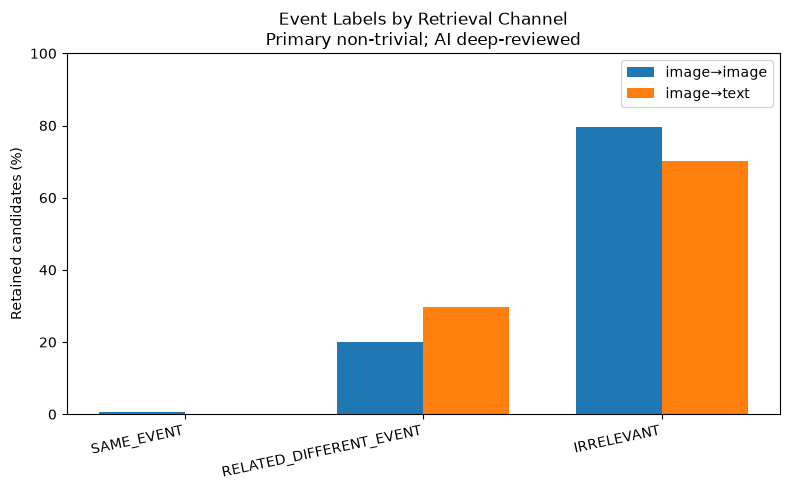

In [32]:
require_phase_b()
import matplotlib.pyplot as plt

phase_b_figures = {}
figure = plt.figure(figsize=(8, 5))
axis = figure.gca()
positions = np.arange(3)
width = 0.36
indexed = main_channel_metrics.set_index('channel')
for index, channel in enumerate(channels):
    percentages = []
    for metric in ['same_rate', 'related_rate', 'irrelevant_rate']:
        percentages.append(100 * indexed.loc[channel, metric])
    offset = (index - 0.5) * width
    axis.bar(positions + offset, percentages, width, label=channel.replace('_to_', '→'))
axis.set_xticks(positions, ['SAME_EVENT', 'RELATED_DIFFERENT_EVENT', 'IRRELEVANT'], rotation=12, ha='right')
axis.set_ylim(0, 100)
axis.set_ylabel('Retained candidates (%)')
axis.set_title('Event Labels by Retrieval Channel\nPrimary non-trivial; AI deep-reviewed')
axis.legend()
figure.tight_layout()
phase_b_figures['event_label_distribution.png'] = figure
plt.show()



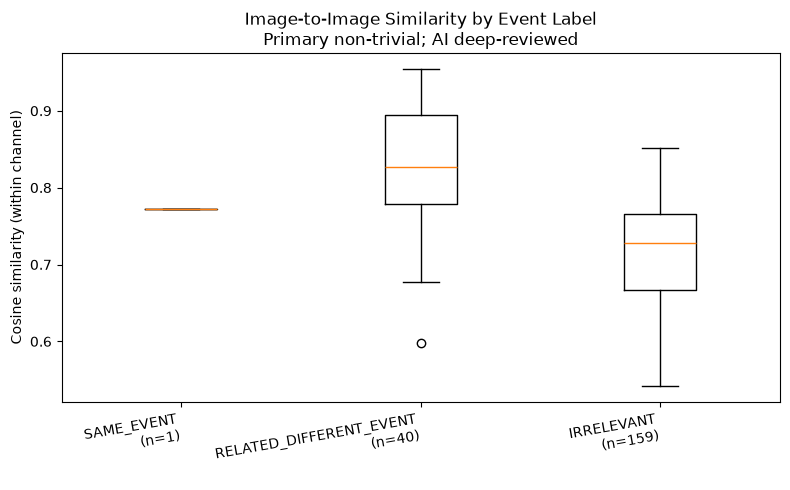

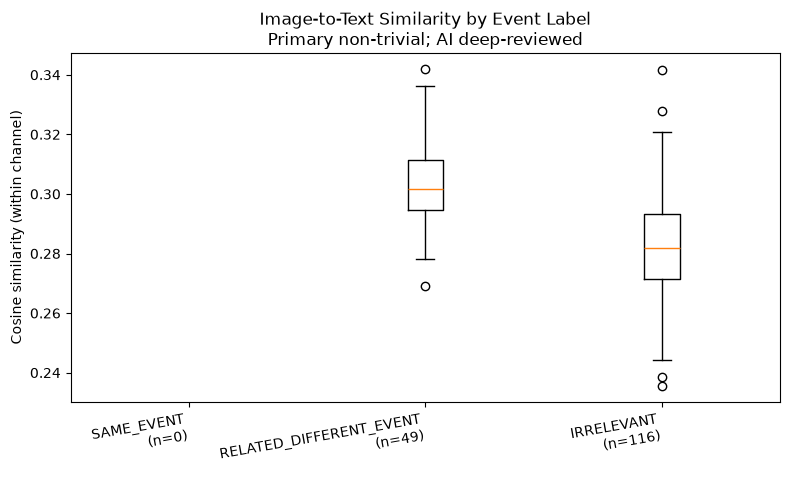

In [33]:
for channel, filename, title in [
    ('image_to_image', 'image_image_similarity_by_event.png', 'Image-to-Image Similarity by Event Label'),
    ('image_to_text', 'image_text_similarity_by_event.png', 'Image-to-Text Similarity by Event Label')
]:
    rows = primary_rows.loc[primary_rows['channel'].eq(channel)]
    groups = []
    positions = []
    labels = []
    for position, label in enumerate(event_labels, start=1):
        scores = rows.loc[rows['event_label'].eq(label), 'similarity']
        labels.append(label + '\n(n=' + str(len(scores)) + ')')
        if len(scores):
            groups.append(scores.to_numpy())
            positions.append(position)
    figure = plt.figure(figsize=(8, 5))
    axis = figure.gca()
    if groups:
        axis.boxplot(groups, positions=positions)
    axis.set_xticks([1, 2, 3], labels, rotation=10, ha='right')
    axis.set_xlim(0.5, 3.5)
    axis.set_ylabel('Cosine similarity (within channel)')
    axis.set_title(title + '\nPrimary non-trivial; AI deep-reviewed')
    figure.tight_layout()
    phase_b_figures[filename] = figure
    plt.show()



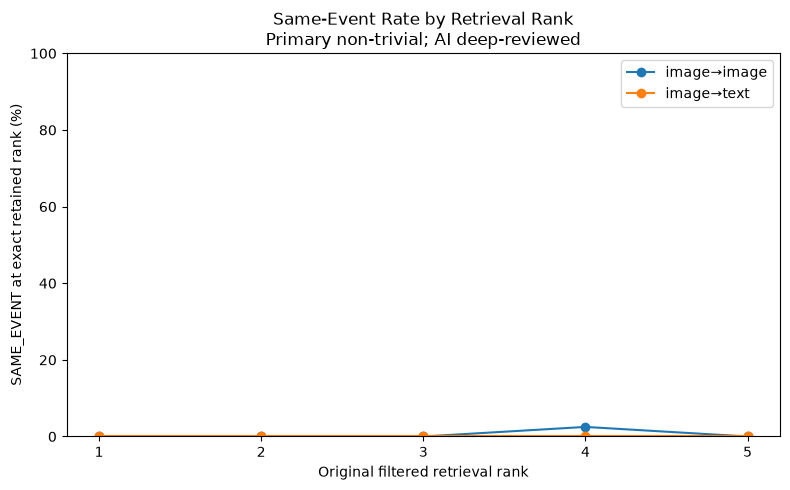

In [34]:
figure = plt.figure(figsize=(8, 5))
axis = figure.gca()
for channel in channels:
    rows = main_rank_metrics.loc[main_rank_metrics['channel'].eq(channel)]
    axis.plot(rows['rank'], 100 * rows['same_rate'], marker='o', label=channel.replace('_to_', '→'))
axis.set_xticks(range(1, 6))
axis.set_ylim(0, 100)
axis.set_xlabel('Original filtered retrieval rank')
axis.set_ylabel('SAME_EVENT at exact retained rank (%)')
axis.set_title('Same-Event Rate by Retrieval Rank\nPrimary non-trivial; AI deep-reviewed')
axis.legend()
figure.tight_layout()
phase_b_figures['same_event_rate_by_rank.png'] = figure
plt.show()



## Readiness

Readiness concerns the next experiment, not final model success. The present primary view has only one independent positive query.
That is too sparse to support broad channel comparisons or scaling a learned reranker yet; useful RELATED cases warrant a larger pilot.



In [35]:
require_phase_b()
primary_same = primary_rows.loc[primary_rows['event_label'].eq('SAME_EVENT')]
positive_query_count = primary_same['query_id'].nunique()
related_count = int(primary_rows['event_label'].eq('RELATED_DIFFERENT_EVENT').sum())
all_sensitivity = sensitivity_analysis.loc[sensitivity_analysis['analysis_view'].eq('all_deep_reviewed')]
clean_sensitivity = sensitivity_analysis.loc[sensitivity_analysis['analysis_view'].eq('exclude_review')]
all_counts = all_sensitivity.set_index('channel')['same_count']
clean_counts = clean_sensitivity.set_index('channel')['same_count']
same_counts_unchanged = all_counts.equals(clean_counts)
sensitivity_interpretation = (
    'Excluding REVIEW rows preserves the one image→image positive and zero image→text positives; '
    'the sparse recovery and related-event failure conclusions remain similar. '
    'Relevant rates decrease by about 3.7 and 4.7 percentage points respectively.'
)
readiness_decision = 'NEEDS_MINOR_FIXES'
readiness_reasons = [
    'Alignment, original retrieval ranks/scores and byte-identity exclusion passed.',
    'Only one non-trivial SAME_EVENT query; image→text has no non-trivial SAME_EVENT examples.',
    'Expand the pilot or improve non-trivial candidate coverage before committing to reranker training.',
    'RELATED events and higher-scoring non-SAME candidates motivate event-aware ranking research.',
    'Separate human review was skipped; uncertainty sensitivity preserves the main descriptive conclusions.'
]
if positive_query_count == 0 or related_count == 0 or not same_counts_unchanged:
    readiness_decision = 'NOT_READY'
    readiness_reasons.append('Non-trivial event variation or uncertainty stability is insufficient.')
print(readiness_decision)
print(sensitivity_interpretation)



NEEDS_MINOR_FIXES
Excluding REVIEW rows preserves the one image→image positive and zero image→text positives; the sparse recovery and related-event failure conclusions remain similar. Relevant rates decrease by about 3.7 and 4.7 percentage points respectively.


## Save

Write analysis tables, plots and summary only. Recheck source hashes so annotation and review artifacts remain unchanged.



In [36]:
def table_records(table):
    # pandas emits null for undefined statistics (empty class or n<2 std).
    return json.loads(table.to_json(orient='records', double_precision=15))


def atomic_output(path, writer, validator):
    with tempfile.NamedTemporaryFile(dir=annotation_dir, suffix=path.suffix, delete=False) as handle:
        temporary_path = Path(handle.name)
    try:
        writer(temporary_path)
        validator(temporary_path)
        temporary_path.replace(path)
    finally:
        temporary_path.unlink(missing_ok=True)


def save_analysis_csv(filename, table):
    def validate(path):
        reloaded = pd.read_csv(path, keep_default_na=False, na_values=[''])
        pd.testing.assert_frame_equal(table.reset_index(drop=True), reloaded,
                                      check_dtype=False, rtol=1e-12, atol=1e-12)
    path = annotation_dir / filename
    atomic_output(path, lambda path: table.to_csv(path, index=False), validate)


def validate_plot(path):
    with Image.open(path) as image:
        if image.format != 'PNG' or image.width < 1 or image.height < 1:
            raise ValueError('Invalid plot output.')
        image.verify()


require_phase_b()
analysis_tables = {
    'pilot_event_channel_metrics.csv': channel_metrics,
    'pilot_event_rank_metrics.csv': rank_metrics,
    'pilot_event_similarity_summary.csv': similarity_summary,
    'pilot_annotation_confidence_summary.csv': confidence_summary,
    'pilot_event_sensitivity_analysis.csv': sensitivity_analysis
}
if phase_b_export_enabled:
    for filename, table in analysis_tables.items():
        save_analysis_csv(filename, table)
    for filename, figure in phase_b_figures.items():
        writer = lambda path, figure=figure: figure.savefig(path, dpi=180, bbox_inches='tight')
        atomic_output(annotation_dir / filename, writer, validate_plot)
    print('Saved five metric tables and four plots.')
else:
    print('Frozen Phase B tables and plots preserved; export disabled.')



Saved five metric tables and four plots.


In [37]:
require_phase_b()
primary_all = channel_metrics['evaluation_view'].eq('primary_nontrivial')
primary_all = primary_all & channel_metrics['analysis_view'].eq('all_deep_reviewed')
inclusive_all = channel_metrics['evaluation_view'].eq('inclusive')
inclusive_all = inclusive_all & channel_metrics['analysis_view'].eq('all_deep_reviewed')
master_review_count = int(phase_b_annotations['review_status'].eq('REVIEW').sum())
summary = {
    'scope': '40 balanced pilot queries; original filtered Top-5; descriptive analysis only',
    'annotation_provenance': {
        'annotation_source': 'AI_ASSISTED_DEEP_REVIEW', 'human_review_completed': False,
        'deep_review_completed': True, 'confidence_scores_calibrated': False,
        'review_rows_retained': True, 'source_file': str(ai_annotation_path),
        'total_annotation_rows': len(phase_b_annotations), 'review_rows': master_review_count,
        'web_checked_rows': int(phase_b_annotations['web_checked'].eq('True').sum()),
        'HIGH': int(phase_b_annotations['annotation_confidence'].eq('HIGH').sum()),
        'MEDIUM': int(phase_b_annotations['annotation_confidence'].eq('MEDIUM').sum()),
        'LOW': int(phase_b_annotations['annotation_confidence'].eq('LOW').sum())
    },
    'validation': {
        'passed': phase_b_validated, 'protected_metadata_unchanged': True,
        'filtered_retrieval_alignment_passed': True, 'frozen_input_hashes_passed': True,
        'unflagged_query_linked_byte_identity_count': 0, 'source_sha256': source_hashes,
        'review_rows_allowed': True, 'model_trained': False, 'completed_csv_created': False
    },
    'label_counts': {label: int(label_counts.get(label, 0)) for label in event_labels},
    'confidence': {
        'HIGH': int(phase_b_annotations['annotation_confidence'].eq('HIGH').sum()),
        'MEDIUM': int(phase_b_annotations['annotation_confidence'].eq('MEDIUM').sum()),
        'LOW': int(phase_b_annotations['annotation_confidence'].eq('LOW').sum()),
        'score_count': len(confidence_scores), 'score_mean': float(confidence_scores.mean()),
        'score_median': float(confidence_scores.median()), 'score_min': int(confidence_scores.min()),
        'score_max': int(confidence_scores.max()),
        'score_bins': {name: int(mask.sum()) for name, mask in score_bins.items()},
        'calibrated_probability': False
    },
    'review_status': {
        'LABELED': int(phase_b_annotations['review_status'].eq('LABELED').sum()),
        'REVIEW': master_review_count,
        'needs_review': int(phase_b_annotations['needs_review'].eq('True').sum())
    },
    'web_verification': {
        'checked_count': int(phase_b_annotations['web_checked'].eq('True').sum()),
        'meaning': 'Extra verification attempted; not automatically more correct.'
    },
    'deep_review_audit': {
        'first_pass_label_changes': len(changes) if changes is not None else None,
        'high_audit_sample_size': audit_count, 'agreement_count': agreement_count,
        'agreement_rate': agreement_rate, 'interpretation': 'Quality-control agreement, not annotation accuracy.'
    },
    'primary_channel_metrics': table_records(channel_metrics.loc[primary_all]),
    'inclusive_channel_metrics': table_records(channel_metrics.loc[inclusive_all]),
    'rank_metrics': table_records(rank_metrics), 'similarity_summary': table_records(similarity_summary),
    'similarity_diagnostics': {
        'within_channel_upper_quartile': table_records(high_score_summary),
        'image_image_non_same_above_sole_same_score': higher_scoring_non_same_count,
        'limitation': 'One primary SAME_EVENT observation in image→image; none in image→text; class separation unestablished.'
    },
    'sensitivity_analysis': {
        'results': table_records(sensitivity_analysis), 'changes_percentage_points': table_records(sensitivity_delta_table),
        'same_positive_counts_unchanged': same_counts_unchanged, 'interpretation': sensitivity_interpretation
    },
    'excluded_trivial_rows': {
        'channels': table_records(exclusion_summary), 'anchor_only_rows_excluded': anchor_only_count,
        'known_visual_group_rule': 'Keep highest original rank per query/channel/group; no rank refill.'
    },
    'metric_definitions': {
        'event_rates': 'Label count / retained candidate count in that channel/view.',
        'topK_rates': 'Label count / retained candidates with original rank <=K; not Recall@K.',
        'query_topK_rates': 'Queries with >=1 matching candidate at original ranks <=K / all 40 pilot queries.',
        'sensitivity': 'Remove REVIEW or needs_review=True; original ranks and fixed query cohort remain.'
    },
    'pilot_readiness': {
        'decision': readiness_decision, 'reasons': readiness_reasons,
        'nontrivial_same_query_count': int(positive_query_count),
        'strongest_same_event_channel': 'image_to_image (one observed positive; tentative)',
        'main_failure_mode': 'High similarity returns related or irrelevant occurrences; independent SAME_EVENT coverage is sparse.',
        'next_experiment_not_final_model_success': True
    },
    'outputs': list(analysis_tables) + list(phase_b_figures) + [summary_path.name],
    'created_at_utc': datetime.now(timezone.utc).isoformat()
}


def validate_summary(path):
    if json.loads(path.read_text()) != summary:
        raise ValueError('Summary round-trip failed.')


writer = lambda path: path.write_text(json.dumps(summary, indent=2, allow_nan=False))
if phase_b_export_enabled:
    atomic_output(summary_path, writer, validate_summary)
require_phase_b()
print('Phase B summary export enabled:', phase_b_export_enabled)
print('Readiness:', readiness_decision)



Summary saved; annotation, template, queue and audit hashes unchanged.
Readiness: NEEDS_MINOR_FIXES


## Conclusion

- Validation passed for all 371 AI-assisted, deep-reviewed rows; 24 REVIEW rows remain visible.
- Primary image→image: SAME 0.50%, RELATED 20.00%, RELEVANT 20.50% (200 candidates).
- Primary image→text: SAME 0.00%, RELATED/RELEVANT 29.70% (165 candidates).
- Image→image is tentatively stronger for SAME_EVENT: one positive at rank 4; image→text has none.
- Candidate Top-1/3/5 SAME rates are 0/0/0.50% versus 0/0/0%; image→image Top-5 query coverage is 1/40.
- Inclusive image→text SAME is 17.50%, entirely explained by 35 exact query images; five anchor-only rows are excluded.
- RELATED evidence is common enough to justify separating thematic support from the same real-world event.
- Cosine alone does not establish identity: 66 non-SAME image→image candidates outscore the sole SAME candidate.
- Excluding REVIEW preserves SAME counts; RELEVANT falls to 16.75% and 25.00%, preserving the main conclusions.
- **NEEDS_MINOR_FIXES**: expand non-trivial positive coverage before reranker development; no model success is established.
- No human review was performed; AI confidence is uncalibrated and 30/30 audit agreement is quality control.


## Deeper Rank Coverage

Frozen cohort: 40 queries and the existing 5,000 evidence items. Only the existing filtered Top-50 image→image and image→text results are used. This is **non-trivial SAME_EVENT query coverage**, not Recall@K: no exhaustive corpus-level gold target set exists.

New labels follow actual query/candidate image inspection plus caption/title/source and occurrence reasoning. Expand independently by channel through Top-10, Top-20, then Top-50 until the first positive; reuse existing pair labels across channels. A staged contact-sheet review may include other candidates in the same stopping stage. Previously labeled pairs outside a stopped prefix are reused without further annotation. Exact path/byte identity, query-linked duplicates and direct provenance identity are excluded; unrelated known duplicate groups retain their highest original rank without refilling ranks.

Same team/person/topic/competition at a different match, round, year or occasion is not SAME_EVENT. Article timestamps are not automatically capture dates. Static objects and undated portraits remain in the fixed 40-query denominator; appearance alone does not establish an occurrence. No falsified flag, dataset-construction metadata or similarity score supplied event truth. Labels remain AI-assisted, with no completed human review; confidence scores are judgments, not calibrated probabilities. The new file contains unique newly inspected pairs only; it is not a dense, randomly sampled annotation set.

In [43]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

coverage_root = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
                     if (p / 'data/manifests/pilot_queries.parquet').is_file())
coverage_dir = coverage_root / 'outputs/pilot/event_annotation'
coverage_config = json.loads((coverage_dir / 'event_annotation_config.json').read_text())
coverage_hashes = {'outputs/pilot/event_annotation/same_event_rate_by_rank.png': '70e397ee26218edb84626e6e9415dcc83e827d10c4874d35be1d006b82748234', 'outputs/pilot/event_annotation/pilot_event_rank_metrics.csv': '861cef8609d7a985627644a563bc743b888cd45a5d2f2a52793c4e4be5d9f46f', 'outputs/pilot/event_annotation/.DS_Store': 'a663de7a4a504af0bca6e834510f04d44714781ac8670d4035ea97002c1f30a3', 'outputs/pilot/event_annotation/.deep_review_state.json': 'cf0041abb2a2e09fe29db81cd0fd04d128e4ab3b9f98e38af125fdc625747dc7', 'outputs/pilot/event_annotation/pilot_event_similarity_summary.csv': '136b3f0802aa0b85bcb995116c635cb18e83df6c8c2755376515c8a57ef7b845', 'outputs/pilot/event_annotation/image_text_similarity_by_event.png': 'fa50a92df5891842e45d897f80adc86593b2f8b75a8181b39c428f17280166ab', 'outputs/pilot/event_annotation/deep_review_changes.csv': 'c2829f94382529381c7a6d3248107677ad40ed93ef2be276fab0060ea7b5cef1', 'outputs/pilot/event_annotation/pilot_event_annotations_ai_assisted.csv': '0fa16143f37f2023c77a37084b32dd45a5b153e554c047f9cdbefc2e3039a7dd', 'outputs/pilot/event_annotation/pilot_event_review_queue.csv': 'b7c415464c7a0c36a12682e17888e94b15c207de67a1c31d8ef9e666f41091e4', 'outputs/pilot/event_annotation/image_image_similarity_by_event.png': 'ca454313dff50157fe8a3d8af19a35ee31cb927a657f788dcf4bf1e1b77deab7', 'outputs/pilot/event_annotation/pilot_event_analysis_summary.json': '7d3a628cb57db41dc5f77f957f57ae988d9be17b654a2b4b197adad2b1310d63', 'outputs/pilot/event_annotation/pilot_event_annotation_template.parquet': '3123a3d6b77e02ecd241b0b17dd112093e04c857a84e172192f7b129318d2d88', 'outputs/pilot/event_annotation/pilot_annotation_confidence_summary.csv': '7bed2b84be5f8629ed7822c4ad488c3637ef9dfc9d798fedad5446e29b98e555', 'outputs/pilot/event_annotation/event_label_distribution.png': '2485c2fff77b38ce0f3180aec54751a94fb43998f63fc324570a1c857475368b', 'outputs/pilot/event_annotation/event_annotation_config.json': '88647b257afb2a9424a7e5de433d49d4654fc3c09dd1b2208a98e0cc167234a1', 'outputs/pilot/event_annotation/pilot_event_channel_metrics.csv': 'aa096e1ae9f183e551d744f5d87c601f79e6b1141542612eaa4ffef3af201776', 'outputs/pilot/event_annotation/pilot_event_annotation_template.csv': '8fa4bd2336148859ee8364556ea8bff0f0f70e79de4a2747a5a6ed50d24af427', 'outputs/pilot/event_annotation/annotation_image_paths.txt': '0785e15523dfa54eae5bece2acfbf88c40f47ded8ff2aa830dd3d9b8095d5d51', 'outputs/pilot/event_annotation/pilot_event_sensitivity_analysis.csv': '242081137de040cf76342c80315807af4603369c8ea3813b3701ee7f6376ba12', 'outputs/pilot/event_annotation/high_confidence_audit.csv': '37350cd79032960e6248379cb96092b6f7bf325bbe8c870f6efd57dd82b4fa8f', 'outputs/pilot/faiss_retrieval/image_to_image_raw.parquet': 'ca2436a749110d12e84d802dc87278eb459c4684cc41b888760478c5747ad91e', 'outputs/pilot/faiss_retrieval/text_to_text_filtered.parquet': 'ad4062f0fe0324bb6e19b8b45980634a5a6cf15dedff84ba59c91e06a5b41c17', 'outputs/pilot/faiss_retrieval/evidence_image.index': '9c27bdd140302d9de84d7062663a79263a9f92fd807e86783323b768e1a1cdf2', 'outputs/pilot/faiss_retrieval/evidence_text.index': '113b1feb9058412543702a9e15accc802da1e77202fcc196a7c8bfa76ac0aec2', 'outputs/pilot/faiss_retrieval/retrieval_metrics.json': '367be99b78ae3ad66c52b3e382c3b1eb40806e7533d33cfed53fa795da66b607', 'outputs/pilot/faiss_retrieval/image_to_text_raw.parquet': '1bc59cbe6a0a45b89cc3fe292b147d3b5e4489bd303918390db9dd3d9891ee19', 'outputs/pilot/faiss_retrieval/image_to_text_filtered.parquet': 'ca92924127f8e7fde2bd50c3c42c0edc04c465c52511809a5fc5cb54a4803b4a', 'outputs/pilot/faiss_retrieval/image_to_image_filtered.parquet': '47f7641536f72f0aae645df9e85410b5b7557c6112291516d1455de6cdc3613a', 'outputs/pilot/faiss_retrieval/retrieval_config.json': '43750a558c2713334175e0df27b6c23fc04f674ac2ef8117ab5fcaeae7bc6d84', 'outputs/pilot/faiss_retrieval/text_to_text_raw.parquet': '4d095f79ba6200b96fd7c98a1da800765aad487efb6ec00002e18e12e46c217b', 'data/manifests/pilot_evidence.parquet': '1bba9b65061dced0d5a3b83def554796ec39f835902e683196d8995e42b7da3e', 'data/manifests/.gitkeep': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'data/manifests/pilot_image_assets.parquet': 'da8de7585b7ab62481cdf2854a53df2fcdc4324725f2b11a3ecd86f2b212c746', 'data/manifests/pilot_queries.parquet': '837b59d79d1817d5260e9eceddec581ed1356d53dddbb21452852a666def2934'}

def verify_coverage_inputs():
    for name, expected in coverage_hashes.items():
        assert hashlib.sha256((coverage_root / name).read_bytes()).hexdigest() == expected, name
    for name, expected in coverage_config['input_sha256'].items():
        assert hashlib.sha256((coverage_root / name).read_bytes()).hexdigest() == expected, name

verify_coverage_inputs()
coverage_query_rows = coverage_config['selected_query_rows']
coverage_queries = pd.read_parquet(coverage_root / 'data/manifests/pilot_queries.parquet').reset_index(names='query_row')
coverage_queries = coverage_queries.set_index('query_row').loc[coverage_query_rows].reset_index()
coverage_evidence = pd.read_parquet(coverage_root / 'data/manifests/pilot_evidence.parquet')
assert len(coverage_queries) == 40 and coverage_queries.query_id.nunique() == 40
assert len(coverage_evidence) == 5000 and coverage_evidence.id.is_unique
coverage_old = pd.read_csv(coverage_dir / 'pilot_event_annotations_ai_assisted.csv', dtype=str, keep_default_na=False)
coverage_new = pd.read_csv(coverage_dir / 'pilot_deeper_rank_event_annotations.csv', dtype={'query_id':str, 'candidate_evidence_id':str}, keep_default_na=False)
coverage_channels = ['image_to_image', 'image_to_text']
coverage_depths = [5, 10, 20, 50]
print('Frozen inputs and prior outputs verified; 40 queries, 5,000 evidence items.')


Frozen inputs and prior outputs verified; 40 queries, 5,000 evidence items.


Matplotlib is building the font cache; this may take a moment.


In [44]:
def coverage_bool(value):
    return str(value).lower() == 'true'

pair_keys = ['query_id', 'candidate_evidence_id']
assert not coverage_old.duplicated(pair_keys).any()
assert not coverage_new.duplicated(pair_keys).any()
old_keys = set(map(tuple, coverage_old[pair_keys].values))
assert not old_keys.intersection(map(tuple, coverage_new[pair_keys].values))
allowed_labels = {'SAME_EVENT', 'RELATED_DIFFERENT_EVENT', 'IRRELEVANT'}
assert set(coverage_new.event_label) <= allowed_labels
assert coverage_new.image_inspected.map(coverage_bool).all()
assert (coverage_new['rank'] > 5).all()
assert coverage_new.confidence_score.between(0, 100).all()
assert set(coverage_new.review_status) <= {'LABELED', 'REVIEW'}
assert coverage_new.is_nontrivial_same.map(coverage_bool).equals(coverage_new.event_label.eq('SAME_EVENT'))
coverage_pair_labels = pd.concat([coverage_old, coverage_new], ignore_index=True).set_index(pair_keys)
coverage_image_root = coverage_root / 'data/pilot/images/pilot_images'
coverage_digest_cache = {}

def coverage_image_digest(relative):
    if relative not in coverage_digest_cache:
        coverage_digest_cache[relative] = hashlib.sha256((coverage_image_root / relative).read_bytes()).hexdigest()
    return coverage_digest_cache[relative]

coverage_new_keys = set(map(tuple, coverage_new[pair_keys].values))
coverage_positions = []
query_lookup = coverage_queries.set_index('query_row')
evidence_lookup = coverage_evidence.assign(id=coverage_evidence.id.astype(str)).set_index('id')
for channel in coverage_channels:
    retrieval = pd.read_parquet(coverage_root / 'outputs/pilot/faiss_retrieval' / f'{channel}_filtered.parquet')
    retrieval = retrieval.loc[retrieval.query_row.isin(coverage_query_rows)]
    assert len(retrieval) == 2000 and retrieval.groupby('query_row').size().eq(50).all()
    assert not retrieval.duplicated(['query_id', 'filtered_rank']).any()
    assert not retrieval.duplicated(['query_id', 'evidence_id']).any()
    for item in retrieval.to_dict('records'):
        query = query_lookup.loc[item['query_row']]
        candidate = evidence_lookup.loc[str(item['evidence_id'])]
        assert item['query_id'] == query['query_id']
        assert item['query_image_path'] == query['query_image_path']
        assert item['evidence_image_path'] == candidate['image_path']
        assert item['evidence_caption'] == candidate['caption']
        key = (item['query_id'], str(item['evidence_id']))
        label = coverage_pair_labels.loc[key] if key in coverage_pair_labels.index else None
        same_bytes = coverage_image_digest(query['query_image_path']) == coverage_image_digest(candidate['image_path'])
        trivial = (query['query_image_path'] == candidate['image_path'] or same_bytes
                   or coverage_bool(item['is_same_image_id'])
                   or (label is not None and coverage_bool(label.get('is_query_linked_duplicate', False))))
        if key in coverage_new_keys:
            assert not trivial
            assert label['candidate_image_path'] == candidate['image_path']
            assert label['candidate_caption'] == candidate['caption']
            assert label['candidate_title'] == candidate['title']
            assert label['candidate_source'] == candidate['source']
        coverage_positions.append(dict(query_row=int(item['query_row']), query_id=item['query_id'],
            channel=channel, rank=int(item['filtered_rank']), candidate_evidence_id=str(item['evidence_id']),
            event_label=label['event_label'] if label is not None else '',
            reviewed=label is not None or trivial, trivial=trivial,
            review_flag=label is not None and coverage_bool(label.get('needs_review',False)),
            known_duplicate_group=item['known_duplicate_group'] or ''))
coverage_positions = pd.DataFrame(coverage_positions).sort_values(['query_row','channel','rank'])
coverage_positions['is_nontrivial_same'] = coverage_positions.event_label.eq('SAME_EVENT') & ~coverage_positions.trivial
# Preserve the Phase B one-known-visual-group-per-query/channel rule.
known_group = coverage_positions.known_duplicate_group.ne('')
duplicate_later = coverage_positions.loc[known_group].duplicated(['query_id','channel','known_duplicate_group'])
coverage_positions.loc[duplicate_later.index[duplicate_later], 'is_nontrivial_same'] = False
print('Validated 4,000 retrieval positions, unique new pairs and image/metadata alignment.')


Validated 4,000 retrieval positions, unique new pairs and image/metadata alignment.


In [45]:
first_rows = []
for query in coverage_queries.to_dict('records'):
    for channel in coverage_channels:
        positions = coverage_positions.loc[coverage_positions.query_id.eq(query['query_id']) & coverage_positions.channel.eq(channel)].sort_values('rank')
        assert positions['rank'].tolist() == list(range(1,51))
        positives = positions.loc[positions.is_nontrivial_same]
        first = int(positives['rank'].min()) if len(positives) else None
        target = first if first is not None else 50
        assert positions.loc[positions['rank'].le(target), 'reviewed'].all(), (query['query_id'],channel)
        checked = 0
        for reviewed in positions.reviewed:
            if not reviewed: break
            checked += 1
        first_rows.append(dict(query_row=query['query_row'], query_id=query['query_id'], channel=channel,
            first_nontrivial_same_rank=first, same_found=first is not None, max_depth_checked=checked))
coverage_first = pd.DataFrame(first_rows)
coverage_first['first_nontrivial_same_rank'] = coverage_first.first_nontrivial_same_rank.astype('Int64')
assert len(coverage_first) == 80
assert coverage_first.loc[~coverage_first.same_found,'max_depth_checked'].eq(50).all()
coverage_records = []
for channel in [*coverage_channels, 'union']:
    selected = coverage_first if channel == 'union' else coverage_first.loc[coverage_first.channel.eq(channel)]
    for depth in coverage_depths:
        count = selected.loc[selected.first_nontrivial_same_rank.le(depth).fillna(False), 'query_id'].nunique()
        coverage_records.append(dict(channel=channel,depth=depth,query_count=40,
            queries_with_nontrivial_same=count,coverage_rate=count/40))
coverage_table = pd.DataFrame(coverage_records)
assert len(coverage_table) == 12
for channel in [*coverage_channels,'union']:
    rates = coverage_table.loc[coverage_table.channel.eq(channel),'coverage_rate']
    assert rates.between(0,1).all() and rates.is_monotonic_increasing
for depth in coverage_depths:
    counts = coverage_table.loc[coverage_table.depth.eq(depth)].set_index('channel').queries_with_nontrivial_same
    assert max(counts[c] for c in coverage_channels) <= counts['union'] <= sum(counts[c] for c in coverage_channels)
# Review exclusions leave the positive discovery curve unchanged.
assert not coverage_positions.loc[coverage_positions.is_nontrivial_same, 'review_flag'].any()
coverage_stats = {}
for channel in [*coverage_channels, 'union']:
    selected = coverage_first if channel == 'union' else coverage_first.loc[coverage_first.channel.eq(channel)]
    ranks = selected.groupby('query_id').first_nontrivial_same_rank.min().dropna().astype(int)
    coverage_stats[channel] = dict(queries_with_same=len(ranks), queries_without_same_at_50=40-len(ranks),
        median_first_same_rank=float(ranks.median()) if len(ranks) else None,
        min_first_same_rank=int(ranks.min()) if len(ranks) else None,
        max_first_same_rank=int(ranks.max()) if len(ranks) else None,
        first_same_ranks=sorted(ranks.tolist()))
display(coverage_table)
display(coverage_first.loc[coverage_first.same_found])
print('First-rank summaries:', coverage_stats)


First-rank summaries: {'image_to_image': {'queries_with_same': 3, 'queries_without_same_at_50': 37, 'median_first_same_rank': 13.0, 'min_first_same_rank': 4, 'max_first_same_rank': 15, 'first_same_ranks': [4, 13, 15]}, 'image_to_text': {'queries_with_same': 3, 'queries_without_same_at_50': 37, 'median_first_same_rank': 48.0, 'min_first_same_rank': 18, 'max_first_same_rank': 50, 'first_same_ranks': [18, 48, 50]}, 'union': {'queries_with_same': 3, 'queries_without_same_at_50': 37, 'median_first_same_rank': 13.0, 'min_first_same_rank': 4, 'max_first_same_rank': 15, 'first_same_ranks': [4, 13, 15]}}


,channel,depth,query_count,queries_with_nontrivial_same,coverage_rate
0,image_to_image,5,40,1,0.025
1,image_to_image,10,40,1,0.025
2,image_to_image,20,40,3,0.075
3,image_to_image,50,40,3,0.075
4,image_to_text,5,40,0,0.000
5,image_to_text,10,40,0,0.000
6,image_to_text,20,40,1,0.025
7,image_to_text,50,40,3,0.075
8,union,5,40,1,0.025
9,union,10,40,1,0.025


,query_row,query_id,channel,first_nontrivial_same_rank,same_found,max_depth_checked
0,199,Q0200,image_to_image,13,True,20
1,199,Q0200,image_to_text,18,True,20
16,92,Q0093,image_to_image,15,True,20
17,92,Q0093,image_to_text,50,True,50
50,106,Q0107,image_to_image,4,True,5
51,106,Q0107,image_to_text,48,True,48


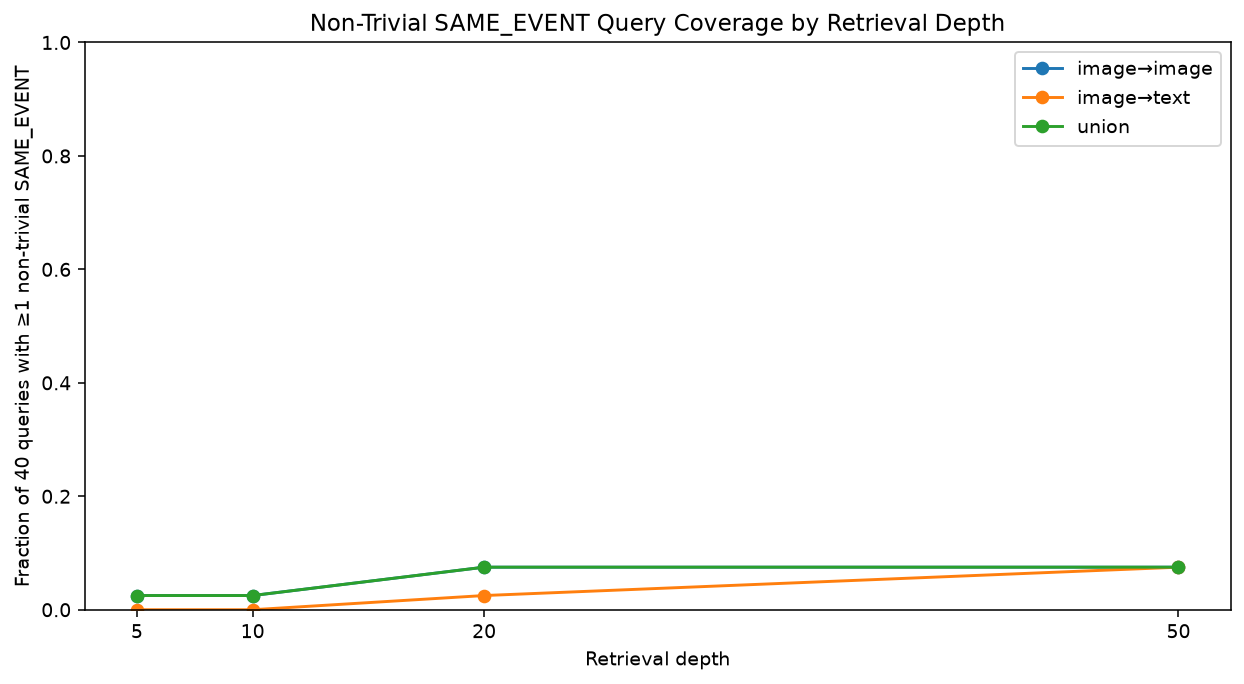

In [46]:
fig, ax = plt.subplots(figsize=(9,5))
for channel, label in [('image_to_image','image→image'),('image_to_text','image→text'),('union','union')]:
    table = coverage_table.loc[coverage_table.channel.eq(channel)]
    ax.plot(table.depth, table.coverage_rate, marker='o', label=label)
ax.set(title='Non-Trivial SAME_EVENT Query Coverage by Retrieval Depth',
       xlabel='Retrieval depth', ylabel='Fraction of 40 queries with ≥1 non-trivial SAME_EVENT')
ax.set_xticks(coverage_depths)
ax.set_ylim(0,1)
ax.legend()
fig.tight_layout()
from io import BytesIO
from IPython.display import Image as DisplayImage
coverage_plot_buffer = BytesIO()
fig.savefig(coverage_plot_buffer, format='png', dpi=140, bbox_inches='tight')
display(DisplayImage(data=coverage_plot_buffer.getvalue()))


In [47]:
coverage_summary = {
    'query_count':40, 'evidence_count':5000, 'channels':coverage_channels + ['union'], 'depths':coverage_depths,
    'new_candidates_inspected':len(coverage_new),
    'label_counts':{label:int(coverage_new.event_label.eq(label).sum()) for label in sorted(allowed_labels)},
    'web_checked_count':int(coverage_new.web_checked.map(coverage_bool).sum()),
    'review_count':int(coverage_new.review_status.eq('REVIEW').sum()),
    'coverage_by_depth':json.loads(coverage_table.to_json(orient='records')),
    'first_same_rank_summary':coverage_stats,
    'bottleneck_decision':'MIXED_BOTTLENECK',
    'short_reason':'Union coverage rises from 1/40 at Top-5 to 3/40 at Top-20, then remains 3/40 at Top-50. Two additional queries reveal lower-ranked matches; 37/40 remain uncovered in both retrieved Top-50 lists. Ranking misses are observed, alongside a dominant retrieval-limited evidence coverage gap.',
    'recommended_next_step':'Review these AI-assisted annotations and audit the frozen corpus for the 37 uncovered occurrences before training. Prioritize planning targeted VisualNews evidence expansion with distinct photos of those occurrences; if corpus auditing finds existing positives below rank 50, reconsider ranking first. Do not train from this tiny positive set.',
    'limitations':['Top-50 misses do not prove SAME_EVENT evidence is absent from the full 5,000-item corpus.',
        'AI-assisted labels have no completed human review; confidence scores are not calibrated probabilities.',
        'Adaptive candidate selection and cross-channel reuse make label counts annotation-cost descriptors, not population event rates.',
        'Same article or publication date alone is insufficient to establish event identity; occurrence captions and actual images were used.',
        'Static/undated queries remain in the fixed 40-query denominator; event identity is intrinsically less well specified for them.'],
    'annotation_provenance':{'source':'AI_ASSISTED_DEEPER_RANK_REVIEW','human_review_completed':False,
        'confidence_calibrated':False,'unique_pair_labels_reused_across_channels':True,
        'adaptive_stages':[10,20,50],'review_exclusion_changes_positive_coverage':False},
    'validation':{'passed':True,'retrieval_positions':4000,'first_rank_prefixes_checked':80,
        'frozen_input_and_prior_output_sha256':coverage_hashes,'previous_phase_b_outputs_unchanged':True,
        'new_pairs_disjoint_from_existing':True,'corpus_expanded':False,'embeddings_regenerated':False,
        'faiss_rebuilt':False,'reranker_trained':False},
    'outputs':['pilot_deeper_rank_event_annotations.csv','pilot_same_event_coverage_by_depth.csv',
        'pilot_first_same_event_rank.csv','nontrivial_same_coverage_by_depth.png','pilot_deeper_rank_coverage_summary.json']
}
verify_coverage_inputs()
coverage_table.to_csv(coverage_dir / 'pilot_same_event_coverage_by_depth.csv',index=False)
coverage_first.to_csv(coverage_dir / 'pilot_first_same_event_rank.csv',index=False)
fig.savefig(coverage_dir / 'nontrivial_same_coverage_by_depth.png',dpi=180,bbox_inches='tight')
(coverage_dir / 'pilot_deeper_rank_coverage_summary.json').write_text(json.dumps(coverage_summary,indent=2,allow_nan=False))
for filename, expected in [('pilot_same_event_coverage_by_depth.csv',coverage_table),('pilot_first_same_event_rank.csv',coverage_first)]:
    restored = pd.read_csv(coverage_dir / filename)
    pd.testing.assert_frame_equal(expected,restored,check_dtype=False)
assert json.loads((coverage_dir / 'pilot_deeper_rank_coverage_summary.json').read_text()) == coverage_summary
with Image.open(coverage_dir / 'nontrivial_same_coverage_by_depth.png') as image:
    assert image.format == 'PNG'
    image.verify()
verify_coverage_inputs()
print('Validation passed; five focused outputs saved. No training, corpus expansion, embedding generation or FAISS rebuild.')
print('New labels:',coverage_summary['label_counts'])
print('Web-checked:',coverage_summary['web_checked_count'],'REVIEW:',coverage_summary['review_count'])


Validation passed; five focused outputs saved. No training, corpus expansion, embedding generation or FAISS rebuild.
New labels: {'IRRELEVANT': 2896, 'RELATED_DIFFERENT_EVENT': 104, 'SAME_EVENT': 3}
Web-checked: 4 REVIEW: 3


Coverage increases, but remains sparse. Image→image covers **1/40, 1/40, 3/40, 3/40** at depths 5/10/20/50; image→text covers **0/40, 0/40, 1/40, 3/40**. Union coverage is **1/40, 1/40, 3/40, 3/40**. Image→image finds all three covered queries earlier; text adds no query to the union.

The new positives are a distinct Jiménez photograph from the second round of the 2014 Open (image rank 13), the same-round “Go Rory” roof message (text rank 18), and the Trump–Clinton handshake after the second 2016 presidential debate (image rank 15, reused at text rank 50). The existing Golden Globes distinct-photo pair appears at image rank 4 and text rank 48. First-positive ranks are image **4, 13, 15** (median **13**) and text **18, 48, 50** (median **48**). These medians describe only three covered queries in each channel.

**37/40 queries remain uncovered in both Top-50 lists. MIXED_BOTTLENECK** is the cautious decision: demonstrated ranking misses for two additional queries, with a much larger unresolved coverage gap. This is a retrieval-limited observation, not proof that the full corpus lacks matching evidence. Review the labels and audit the frozen corpus for the uncovered occurrences, then prioritize targeted VisualNews evidence expansion planning before reranker training. The three new SAME_EVENT pairs are too few to support training on their own.

Stop here for user review. No corpus expansion, embedding regeneration, FAISS rebuild or model training was performed; previous annotations and Phase B outputs are preserved.